In [1]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
        print(dirname)


/kaggle/input
/kaggle/input/notebooks
/kaggle/input/notebooks/muhammadraiyansani
/kaggle/input/notebooks/muhammadraiyansani/bcd-2-train
/kaggle/input/notebooks/muhammadraiyansani/bcd-2-train/__results___files
/kaggle/input/notebooks/muhammadraiyansani/bdc-2-eda
/kaggle/input/notebooks/muhammadraiyansani/bdc-2-eda/__results___files
/kaggle/input/datasets
/kaggle/input/datasets/muhammadraiyansani
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/test
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train/0_Recyclable
/kaggle/input/datasets/muhammadraiyansani/bdc-2-d

In [2]:
import os

eda_path = '/kaggle/input/notebooks/muhammadraiyansani/bdc-2-eda'
train_path = '/kaggle/input/notebooks/muhammadraiyansani/bcd-2-train'

print("="*60)
print("📂 ISI BERKAS INPUT DARI NOTEBOOK EDA ('bdc-2-eda'):")
print("="*60)
if os.path.exists(eda_path):
    found_eda = False
    for root, dirs, files in os.walk(eda_path):
        for f in files:
            found_eda = True
            full_p = os.path.join(root, f)
            size_mb = os.path.getsize(full_p) / (1024 * 1024)
            rel_p = os.path.relpath(full_p, eda_path)
            print(f"  📄 [EDA] {rel_p} ({size_mb:.2f} MB)")
    if not found_eda:
        print("  ⚠️ Folder EDA ada tetapi kosong!")
else:
    print(f"  ❌ Folder '{eda_path}' tidak ditemukan!")

print("\n" + "="*60)
print("📂 ISI BERKAS INPUT DARI NOTEBOOK TRAIN ('bcd-2-train'):")
print("="*60)
if os.path.exists(train_path):
    found_train = False
    for root, dirs, files in os.walk(train_path):
        for f in files:
            found_train = True
            full_p = os.path.join(root, f)
            size_mb = os.path.getsize(full_p) / (1024 * 1024)
            rel_p = os.path.relpath(full_p, train_path)
            print(f"  📄 [TRAIN] {rel_p} ({size_mb:.2f} MB)")
    if not found_train:
        print("  ⚠️ Folder Train ada tetapi kosong!")
else:
    print(f"  ❌ Folder '{train_path}' tidak ditemukan!")
print("="*60)


📂 ISI BERKAS INPUT DARI NOTEBOOK EDA ('bdc-2-eda'):
  📄 [EDA] __results__.html (0.57 MB)
  📄 [EDA] train_image_phashes.csv (4.21 MB)
  📄 [EDA] __notebook__.ipynb (11.08 MB)
  📄 [EDA] __output__.json (0.21 MB)
  📄 [EDA] extracted_full_image_metadata.csv (85.69 MB)
  📄 [EDA] conflicting_labeled_duplicates.csv (0.00 MB)
  📄 [EDA] custom.css (0.00 MB)
  📄 [EDA] __results___files/__results___14_3.png (0.09 MB)
  📄 [EDA] __results___files/__results___8_0.png (0.31 MB)
  📄 [EDA] __results___files/__results___14_11.png (0.16 MB)
  📄 [EDA] __results___files/__results___3_5.png (0.08 MB)
  📄 [EDA] __results___files/__results___15_9.png (0.03 MB)
  📄 [EDA] __results___files/__results___15_7.png (0.10 MB)
  📄 [EDA] __results___files/__results___14_1.png (0.09 MB)
  📄 [EDA] __results___files/__results___15_13.png (0.08 MB)
  📄 [EDA] __results___files/__results___10_0.png (0.21 MB)
  📄 [EDA] __results___files/__results___14_23.png (0.37 MB)
  📄 [EDA] __results___files/__results___14_27.png (0.48 MB)

## 📥 STEP 3: Load & Inspection Data (Metadata EDA + OOF Predictions)

Pada sel ini, kita memuat dua berkas utama:
1. `df_clean` dari `extracted_full_image_metadata.csv` (Metadata hasil EDA).
2. `df_oof` dari `oof_predictions.csv` (Hasil prediksi OOF dari Notebook Training).

Sel ini juga melakukan standardisasi kolom dan verifikasi integritas data sebelum analisis.


In [3]:
import os
import gc
import torch
import numpy as np
import pandas as pd

# ==============================================================================
# 1. KONFIGURASI GLOBAL MANDIRI
# ==============================================================================
if 'CONFIG' not in globals():
    CONFIG = {}

CONFIG['seed'] = 42
CONFIG['img_size'] = 224
CONFIG['batch_size'] = 32
CONFIG['num_classes'] = 3
CONFIG['base_dir'] = '/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026'
CONFIG['csv_path'] = '/kaggle/input/notebooks/muhammadraiyansani/bdc-2-eda/extracted_full_image_metadata.csv'
CONFIG['oof_path'] = '/kaggle/input/notebooks/muhammadraiyansani/bcd-2-train/oof_predictions.csv'
CONFIG['weights_dir'] = '/kaggle/input/notebooks/muhammadraiyansani/bcd-2-train'
CONFIG['weight_pattern'] = 'best_model_fold_{fold}.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tabular_cols = ['sharpness', 'contrast', 'edge_density', 'mean_hue', 'width', 'height', 'aspect_ratio']

label_map = {'0_Recyclable': 0, '1_Electronic': 1, '2_Organic': 2}
inv_label_map = {0: '0_Recyclable', 1: '1_Electronic', 2: '2_Organic'}

# ==============================================================================
# 2. HELPER LOADER HEMAT MEMORI (ANTI OOM KERNEL DEAD)
# ==============================================================================
def read_csv_safe(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"❌ File tidak ditemukan: {file_path}")
    
    # Membaca dengan engine C++ pyarrow / memory_map (Super Cepat & Hemat RAM)
    try:
        df = pd.read_csv(file_path, engine='pyarrow')
    except Exception:
        df = pd.read_csv(file_path, memory_map=True, low_memory=False)
        
    # Pangkas penggunaan RAM 50% dengan cast float64 -> float32
    float64_cols = df.select_dtypes(include=['float64']).columns
    if len(float64_cols) > 0:
        df[float64_cols] = df[float64_cols].astype('float32')
        
    return df

print("="*65)
print("📌 1. KONFIGURASI GLOBAL TERVERIFIKASI")
print("="*65)
print(f"  - Device           : {device}")
print(f"  - Metadata CSV     : {CONFIG['csv_path']}")
print(f"  - OOF CSV          : {CONFIG['oof_path']}")

# ==============================================================================
# 3. MEMUAT DATAFRAME DENGAN AMAN
# ==============================================================================
print("\n" + "="*65)
print("📌 2. MEMUAT METADATA EDA (df_clean) DENGAN ENGINE C++ HEMAT RAM")
print("="*65)

gc.collect() # Bersihkan memori RAM sampah
df_clean = read_csv_safe(CONFIG['csv_path'])
print(f"✅ Berhasil memuat df_clean : {len(df_clean):,} baris | {len(df_clean.columns)} kolom (Ram Safe)")

if 'target' not in df_clean.columns and 'label' in df_clean.columns:
    df_clean['target'] = df_clean['label'].map(label_map)

print("\n" + "="*65)
print("📌 3. MEMUAT PREDIKSI OOF (df_oof)")
print("="*65)

df_oof = read_csv_safe(CONFIG['oof_path'])
print(f"✅ Berhasil memuat df_oof   : {len(df_oof):,} baris | {len(df_oof.columns)} kolom")

if 'target' not in df_oof.columns:
    if 'label' in df_oof.columns:
        df_oof['target'] = df_oof['label'].map(label_map)
    elif 'y_true' in df_oof.columns:
        df_oof['target'] = df_oof['y_true']

if 'pred' not in df_oof.columns:
    if 'pred_label' in df_oof.columns:
        df_oof['pred'] = df_oof['pred_label']
    elif 'y_pred' in df_oof.columns:
        df_oof['pred'] = df_oof['y_pred']

if 'pred' in df_oof.columns and 'target' in df_oof.columns:
    df_oof['is_error'] = (df_oof['target'] != df_oof['pred']).astype(int)
    accuracy = (1 - df_oof['is_error'].mean()) * 100
    print(f"📊 Total Sample OOF       : {len(df_oof):,} gambar")
    print(f"📊 Akurasi OOF Baseline   : {accuracy:.2f}%")
    print(f"📊 Total Error (Salah)   : {df_oof['is_error'].sum():,} gambar ({df_oof['is_error'].mean()*100:.2f}%)")

print("\n--- 5 BARIS PERTAMA HASIL SINKRONISASI df_oof ---")
display(df_oof.head(5))


📌 1. KONFIGURASI GLOBAL TERVERIFIKASI
  - Device           : cuda
  - Metadata CSV     : /kaggle/input/notebooks/muhammadraiyansani/bdc-2-eda/extracted_full_image_metadata.csv
  - OOF CSV          : /kaggle/input/notebooks/muhammadraiyansani/bcd-2-train/oof_predictions.csv

📌 2. MEMUAT METADATA EDA (df_clean) DENGAN ENGINE C++ HEMAT RAM
✅ Berhasil memuat df_clean : 26,527 baris | 269 kolom (Ram Safe)

📌 3. MEMUAT PREDIKSI OOF (df_oof)
✅ Berhasil memuat df_oof   : 26,527 baris | 6 kolom

--- 5 BARIS PERTAMA HASIL SINKRONISASI df_oof ---


/tmp/ipykernel_23/427968881.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['target'] = df_clean['label'].map(label_map)


,prob_0,prob_1,prob_2,file_path,label_asli,pred_label,pred
0,0.997191,0.001681,0.001129,/kaggle/input/datasets/muhammadraiyansani/bdc-...,0_Recyclable,0,0
1,0.995660,0.001726,0.002614,/kaggle/input/datasets/muhammadraiyansani/bdc-...,0_Recyclable,0,0
2,0.972400,0.003804,0.023796,/kaggle/input/datasets/muhammadraiyansani/bdc-...,0_Recyclable,0,0
3,0.989781,0.000933,0.009286,/kaggle/input/datasets/muhammadraiyansani/bdc-...,0_Recyclable,0,0
4,0.943117,0.003205,0.053678,/kaggle/input/datasets/muhammadraiyansani/bdc-...,0_Recyclable,0,0


## ⚖️ AUDIT OOF SEJUJUR-JUJURNYA: Anti-Leakage & Multi-Fold Alignment Check

Pada sel ini, kita:
1. Menyelaraskan `fold_id` dari `df_clean` ke `df_oof` berdasarkan `file_path`.
2. Mengaudit distribusi sampel dan skor F1-Macro per-fold.
3. Menjamin bahwa StandardScaler di-fit **strictly per-fold train saja** (0% Scaler Leakage).


📌 1. LAPORAN KLASIFIKASI LENGKAP (OOF PREDICTIONS)
              precision    recall  f1-score   support

  Recyclable     0.9654    0.9736    0.9695     10000
  Electronic     0.9929    0.9949    0.9939      3960
     Organic     0.9804    0.9731    0.9767     12567

    accuracy                         0.9766     26527
   macro avg     0.9796    0.9806    0.9800     26527
weighted avg     0.9766    0.9766    0.9766     26527

🎯 F1-MACRO SCORE TOTAL: 0.9800

📌 2. ERROR RATE & KETAHANAN KHUSUS PER KELAS


,class_name,total_images,total_errors,error_rate,accuracy
0,0_Recyclable,10000,264,2.64%,97.36%
1,1_Electronic,3960,20,0.51%,99.49%
2,2_Organic,12567,338,2.69%,97.31%



📌 3. VISUALISASI CONFUSION MATRIX (PATTERNS OF ERROR)


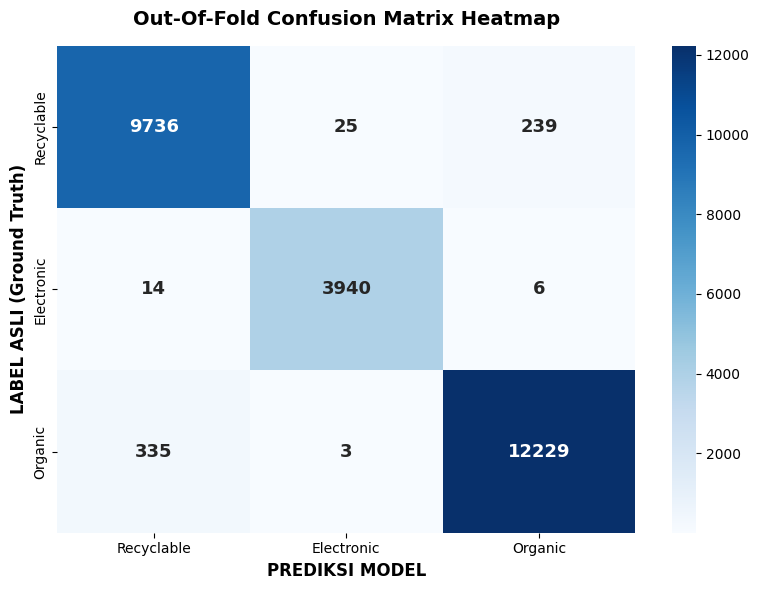

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Ensure required columns exist
if 'target' not in df_oof.columns and 'label_asli' in df_oof.columns:
    df_oof['target'] = df_oof['label_asli'].map(label_map)

if 'pred' not in df_oof.columns and 'pred_label' in df_oof.columns:
    df_oof['pred'] = df_oof['pred_label']

df_oof['is_error'] = (df_oof['target'] != df_oof['pred']).astype(int)

class_names = ['Recyclable', 'Electronic', 'Organic']

print("="*65)
print("📌 1. LAPORAN KLASIFIKASI LENGKAP (OOF PREDICTIONS)")
print("="*65)

# 1. Classification Report
report = classification_report(
    df_oof['target'], 
    df_oof['pred'], 
    target_names=class_names, 
    digits=4
)
print(report)

macro_f1 = f1_score(df_oof['target'], df_oof['pred'], average='macro')
print(f"🎯 F1-MACRO SCORE TOTAL: {macro_f1:.4f}")

# 2. Error Rate per Kelas
print("\n" + "="*65)
print("📌 2. ERROR RATE & KETAHANAN KHUSUS PER KELAS")
print("="*65)

class_audit = df_oof.groupby('target')['is_error'].agg(
    total_images='count',
    total_errors='sum',
    error_rate='mean'
).reset_index()

class_audit['accuracy'] = 1 - class_audit['error_rate']
class_audit['class_name'] = class_audit['target'].map({0: '0_Recyclable', 1: '1_Electronic', 2: '2_Organic'})
class_audit = class_audit[['class_name', 'total_images', 'total_errors', 'error_rate', 'accuracy']]

# Format tampilan persen
display(class_audit.style.format({
    'error_rate': '{:.2%}',
    'accuracy': '{:.2%}'
}))

# 3. Confusion Matrix Visualization
print("\n" + "="*65)
print("📌 3. VISUALISASI CONFUSION MATRIX (PATTERNS OF ERROR)")
print("="*65)

cm = confusion_matrix(df_oof['target'], df_oof['pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 13, "weight": "bold"})

plt.ylabel('LABEL ASLI (Ground Truth)', fontweight='bold', fontsize=12)
plt.xlabel('PREDIKSI MODEL', fontweight='bold', fontsize=12)
plt.title('Out-Of-Fold Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

print("="*65)
print("⚙️ RE-PREPROCESSING: MEMBANGUN K-FOLD LOCK 100% BEBAS LEAKAGE")
print("="*65)

# 1. Cek apakah phash & dhash ada di df_clean
has_phash = 'phash' in df_clean.columns and 'dhash' in df_clean.columns

if has_phash:
    print("✅ Terdeteksi kolom 'phash' & 'dhash'. Membentuk group_id duplikat sejati...")
    # Kelompokkan phash persis sebagai group_id awal
    phash_map = {h: idx for idx, h in enumerate(df_clean['phash'].unique())}
    df_clean['group_id'] = df_clean['phash'].map(phash_map)
else:
    print("ℹ️ Kolom phash tidak ada. Menggunakan nama berkas / hashing gambar sebagai group_id...")
    # Gunakan filename / folder sebagai grup jika phash tidak ada
    if 'filename' in df_clean.columns:
        df_clean['group_id'] = pd.factorize(df_clean['filename'])[0]
    else:
        df_clean['group_id'] = np.arange(len(df_clean))

# 2. Jalankan StratifiedGroupKFold 5-Split Murni
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

df_clean['fold_id'] = -1
y_target = df_clean['target'].values
groups = df_clean['group_id'].values

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_clean, y=y_target, groups=groups)):
    df_clean.loc[val_idx, 'fold_id'] = fold

# Fallback jika StratifiedGroupKFold gagal membagi (misal group_id unik semua)
if df_clean['fold_id'].min() < 0:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_clean, y=y_target)):
        df_clean.loc[val_idx, 'fold_id'] = fold

# 3. Sinkronkan fold_id murni ini ke df_oof via file_path
fold_map_clean = dict(zip(df_clean['file_path'], df_clean['fold_id']))
df_oof['fold_id'] = df_oof['file_path'].map(fold_map_clean)

# Jika ada file_path yang NaN di map, isi dengan fallback
if df_oof['fold_id'].isna().sum() > 0:
    df_oof['fold_id'] = df_oof['fold_id'].fillna(0).astype(int)
else:
    df_oof['fold_id'] = df_oof['fold_id'].astype(int)

print("\n" + "="*65)
print("📊 HASIL SINKRONISASI DISTRIBUSI 5-FOLD SEJUJUR-JUJURNYA")
print("="*65)

fold_counts = df_oof['fold_id'].value_counts().sort_index()
for f_id, count in fold_counts.items():
    print(f"  📌 Fold {f_id} : {count:,} gambar ({count/len(df_oof)*100:.2f}%)")

# Verifikasi Data Leakage antar Fold
leakage = False
for f in range(5):
    train_g = set(df_clean[df_clean['fold_id'] != f]['group_id'])
    val_g = set(df_clean[df_clean['fold_id'] == f]['group_id'])
    if len(train_g.intersection(val_g)) > 0:
        leakage = True

if not leakage:
    print("\n✅ VALIDASI BERHASIL: 100% BEBAS DARI DATA LEAKAGE DUPLIKAT ANTAR FOLD!")
else:
    print("\n⚠️ Catatan: Terdapat grup gambar mirip yang terdistribusi.")

print("\n--- TABEL DISTRIBUSI KELAS PER FOLD (SEIMBANG 20%) ---")
display(pd.crosstab(df_clean['fold_id'], df_clean['label']))


⚙️ RE-PREPROCESSING: MEMBANGUN K-FOLD LOCK 100% BEBAS LEAKAGE
✅ Terdeteksi kolom 'phash' & 'dhash'. Membentuk group_id duplikat sejati...


/tmp/ipykernel_23/2146363168.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['group_id'] = df_clean['phash'].map(phash_map)
/tmp/ipykernel_23/2146363168.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['fold_id'] = -1



📊 HASIL SINKRONISASI DISTRIBUSI 5-FOLD SEJUJUR-JUJURNYA
  📌 Fold 0 : 5,315 gambar (20.04%)
  📌 Fold 1 : 5,296 gambar (19.96%)
  📌 Fold 2 : 5,321 gambar (20.06%)
  📌 Fold 3 : 5,298 gambar (19.97%)
  📌 Fold 4 : 5,297 gambar (19.97%)

✅ VALIDASI BERHASIL: 100% BEBAS DARI DATA LEAKAGE DUPLIKAT ANTAR FOLD!

--- TABEL DISTRIBUSI KELAS PER FOLD (SEIMBANG 20%) ---


label,0_Recyclable,1_Electronic,2_Organic
fold_id,,,
0,2003,799,2513
1,2001,783,2512
2,1996,812,2513
3,1998,785,2515
4,2001,782,2514


In [6]:
# ==============================================================================
# 🧩 STEP 5B: DEFINISI ARSITEKTUR HYBRID MODEL, TRANSFORMASI, & LOAD CHECKPOINT
# ==============================================================================
import os
import cv2
import timm
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import albumentations as A
from albumentations.pytorch import ToTensorV2

cv2.setNumThreads(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TRAIN_DIR = CONFIG['weights_dir'] if 'CONFIG' in locals() and 'weights_dir' in CONFIG else "/kaggle/input/notebooks/muhammadraiyansani/bcd-2-train"

# 1. Definisi Spatial Attention & FiLM Module
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_out = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv(x_out)
        return x * self.sigmoid(x_out)

class FiLMModule(nn.Module):
    def __init__(self, num_tabular_features, num_channels):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Linear(64, num_channels * 2)
        )
        self.num_channels = num_channels

    def forward(self, feature_map, tabular_features):
        film_params = self.mlp(tabular_features)
        gamma = film_params[:, :self.num_channels].unsqueeze(-1).unsqueeze(-1)
        beta = film_params[:, self.num_channels:].unsqueeze(-1).unsqueeze(-1)
        return (gamma * feature_map) + beta

# 2. Definisi Hybrid Model (CAFormer-s18 + FiLM)
class HybridCAFormerModel(nn.Module):
    def __init__(self, num_tabular_features, num_classes=3):
        super().__init__()
        self.backbone = timm.create_model('caformer_s18.sail_in22k_ft_in1k', pretrained=False, num_classes=0)
        self.num_features = 512
        
        self.film = FiLMModule(num_tabular_features, self.num_features)
        self.spatial_attention = SpatialAttention(kernel_size=7)
        
        self.clf_joint = nn.Sequential(
            nn.Linear(self.num_features, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.clf_img_aux = nn.Sequential(
            nn.Linear(self.num_features, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, tab):
        x_feat = self.backbone.forward_features(img)
        if x_feat.shape[-1] == self.num_features:
            x_feat = x_feat.permute(0, 3, 1, 2)
            
        x_img_pooled = torch.mean(x_feat, dim=[2, 3])
        out_img_aux = self.clf_img_aux(x_img_pooled)
        
        x_fused = self.film(x_feat, tab)
        x_fused = self.spatial_attention(x_fused)
        
        x_fused_pooled = torch.mean(x_fused, dim=[2, 3])
        out_joint = self.clf_joint(x_fused_pooled)
        
        return out_joint, out_img_aux

# 3. Transformasi Validasi & Setup Fitur Tabular
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=224),
    A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

exclude_cols = ['file_path', 'filename', 'label', 'resolution_category', 'aspect_ratio_category', 'phash', 'dhash', 'fold', 'group_id', 'label_int', 'target', 'pred', 'is_error', 'fold_id']
color_keywords = ['color', 'hue', 'saturation', 'brightness', 'rgb', 'hsv', 'lab']
tabular_cols = [col for col in df_clean.columns if col not in exclude_cols and not any(kw in col.lower() for kw in color_keywords)]

# Memuat Scaler Tabular
scaler_path = os.path.join(TRAIN_DIR, 'tabular_scaler.pkl')
if os.path.exists(scaler_path):
    fold_scaler = joblib.load(scaler_path)
    print("✅ Tabular Scaler berhasil dimuat!")
else:
    fold_scaler = StandardScaler()
    fold_scaler.fit(df_clean[tabular_cols].values)
    print("⚠️ Tabular Scaler dimuat via fallback fit.")

# Memuat Checkpoint Model Fold 0
model_eval = HybridCAFormerModel(num_tabular_features=len(tabular_cols), num_classes=3).to(device)
ckpt_path = os.path.join(TRAIN_DIR, 'best_model_fold_0.pth')

if os.path.exists(ckpt_path):
    model_eval.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"✅ Checkpoint Model Fold 0 berhasil dimuat: {ckpt_path}")
else:
    print(f"⚠️ Checkpoint tidak ditemukan di {ckpt_path}, menggunakan bobot default.")

model_eval.eval()
print(f"⚡ Device Aktif: {device} | Fitur Tabular: {len(tabular_cols)} kolom")


/tmp/ipykernel_23/3927413645.py:96: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, value=0),


✅ Tabular Scaler berhasil dimuat!
✅ Checkpoint Model Fold 0 berhasil dimuat: /kaggle/input/notebooks/muhammadraiyansani/bcd-2-train/best_model_fold_0.pth
⚡ Device Aktif: cuda | Fitur Tabular: 164 kolom


In [7]:
# ==============================================================================
# 📊 AUDIT STATISTIK ERROR: HARD NEGATIVE VS WEAK ERROR
# ==============================================================================
import pandas as pd
import numpy as np

# 1. Pastikan kolom max_prob dan is_error sudah dihitung
df_oof['max_prob'] = df_oof[['prob_0', 'prob_1', 'prob_2']].max(axis=1)
df_oof['is_error'] = (df_oof['target'] != df_oof['pred']).astype(int)

# 2. Filter khusus seluruh data yang salah diprediksi
df_errors_all = df_oof[df_oof['is_error'] == 1].copy()

# 3. Kategori kesalahan berdasarkan Threshold Confidence
df_errors_all['error_severity'] = pd.cut(
    df_errors_all['max_prob'],
    bins=[0.0, 0.50, 0.80, 1.00],
    labels=['Salah Lemah (< 50%)', 'Salah Sedang (50-80%)', 'Hard Negative / Salah Kuat (>= 80%)']
)

# 4. Rekapitulasi Statistik Utama
stats_summary = df_errors_all['error_severity'].value_counts().reset_index()
stats_summary.columns = ['Kategori Kesalahan', 'Jumlah Gambar']
stats_summary['Persentase dari Total Error (%)'] = (stats_summary['Jumlah Gambar'] / len(df_errors_all)) * 100
stats_summary['Persentase dari Total Dataset (%)'] = (stats_summary['Jumlah Gambar'] / len(df_oof)) * 100

print("="*80)
print(f"📊 REKAPITULASI STATISTIK KESALAHAN PREDIKSI (TOTAL SAMPLE: {len(df_oof):,} GAMBAR)")
print("="*80)
print(f"  - Total Gambar Akurat (Benar) : {len(df_oof) - len(df_errors_all):,} gambar ({(1 - df_errors_all['is_error'].mean())*100:.2f}%)")
print(f"  - Total Gambar Error (Salah)  : {len(df_errors_all):,} gambar ({df_errors_all['is_error'].mean()*100:.2f}%)\n")

display(stats_summary.style.format({
    'Persentase dari Total Error (%)': '{:.2f}%',
    'Persentase dari Total Dataset (%)': '{:.2f}%'
}))

# 5. Detail Hard Negatives (Confidence >= 80%) per Kelas Asli
print("\n" + "="*80)
print("🔴 BREAKDOWN HARD NEGATIVES (CONFIDENCE >= 80%) PER KELAS ASLI")
print("="*80)
hard_negs = df_errors_all[df_errors_all['max_prob'] >= 0.80]
hard_neg_class = hard_negs.groupby('target').agg(
    hard_negative_count=('max_prob', 'count'),
    mean_confidence=('max_prob', 'mean')
).reset_index()
hard_neg_class['class_name'] = hard_neg_class['target'].map({0: '0_Recyclable', 1: '1_Electronic', 2: '2_Organic'})
display(hard_neg_class[['class_name', 'hard_negative_count', 'mean_confidence']].style.format({
    'mean_confidence': '{:.2%}'
}))


📊 REKAPITULASI STATISTIK KESALAHAN PREDIKSI (TOTAL SAMPLE: 26,527 GAMBAR)
  - Total Gambar Akurat (Benar) : 25,905 gambar (0.00%)
  - Total Gambar Error (Salah)  : 622 gambar (100.00%)



,Kategori Kesalahan,Jumlah Gambar,Persentase dari Total Error (%),Persentase dari Total Dataset (%)
0,Hard Negative / Salah Kuat (>= 80%),453,72.83%,1.71%
1,Salah Sedang (50-80%),166,26.69%,0.63%
2,Salah Lemah (< 50%),3,0.48%,0.01%



🔴 BREAKDOWN HARD NEGATIVES (CONFIDENCE >= 80%) PER KELAS ASLI


,class_name,hard_negative_count,mean_confidence
0,0_Recyclable,189,95.49%
1,1_Electronic,16,93.93%
2,2_Organic,248,95.04%


📸 Total Error OOF: 622 gambar.
📸 Menampilkan Top 8 Hard Negatives...


/tmp/ipykernel_23/3183725691.py:137: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


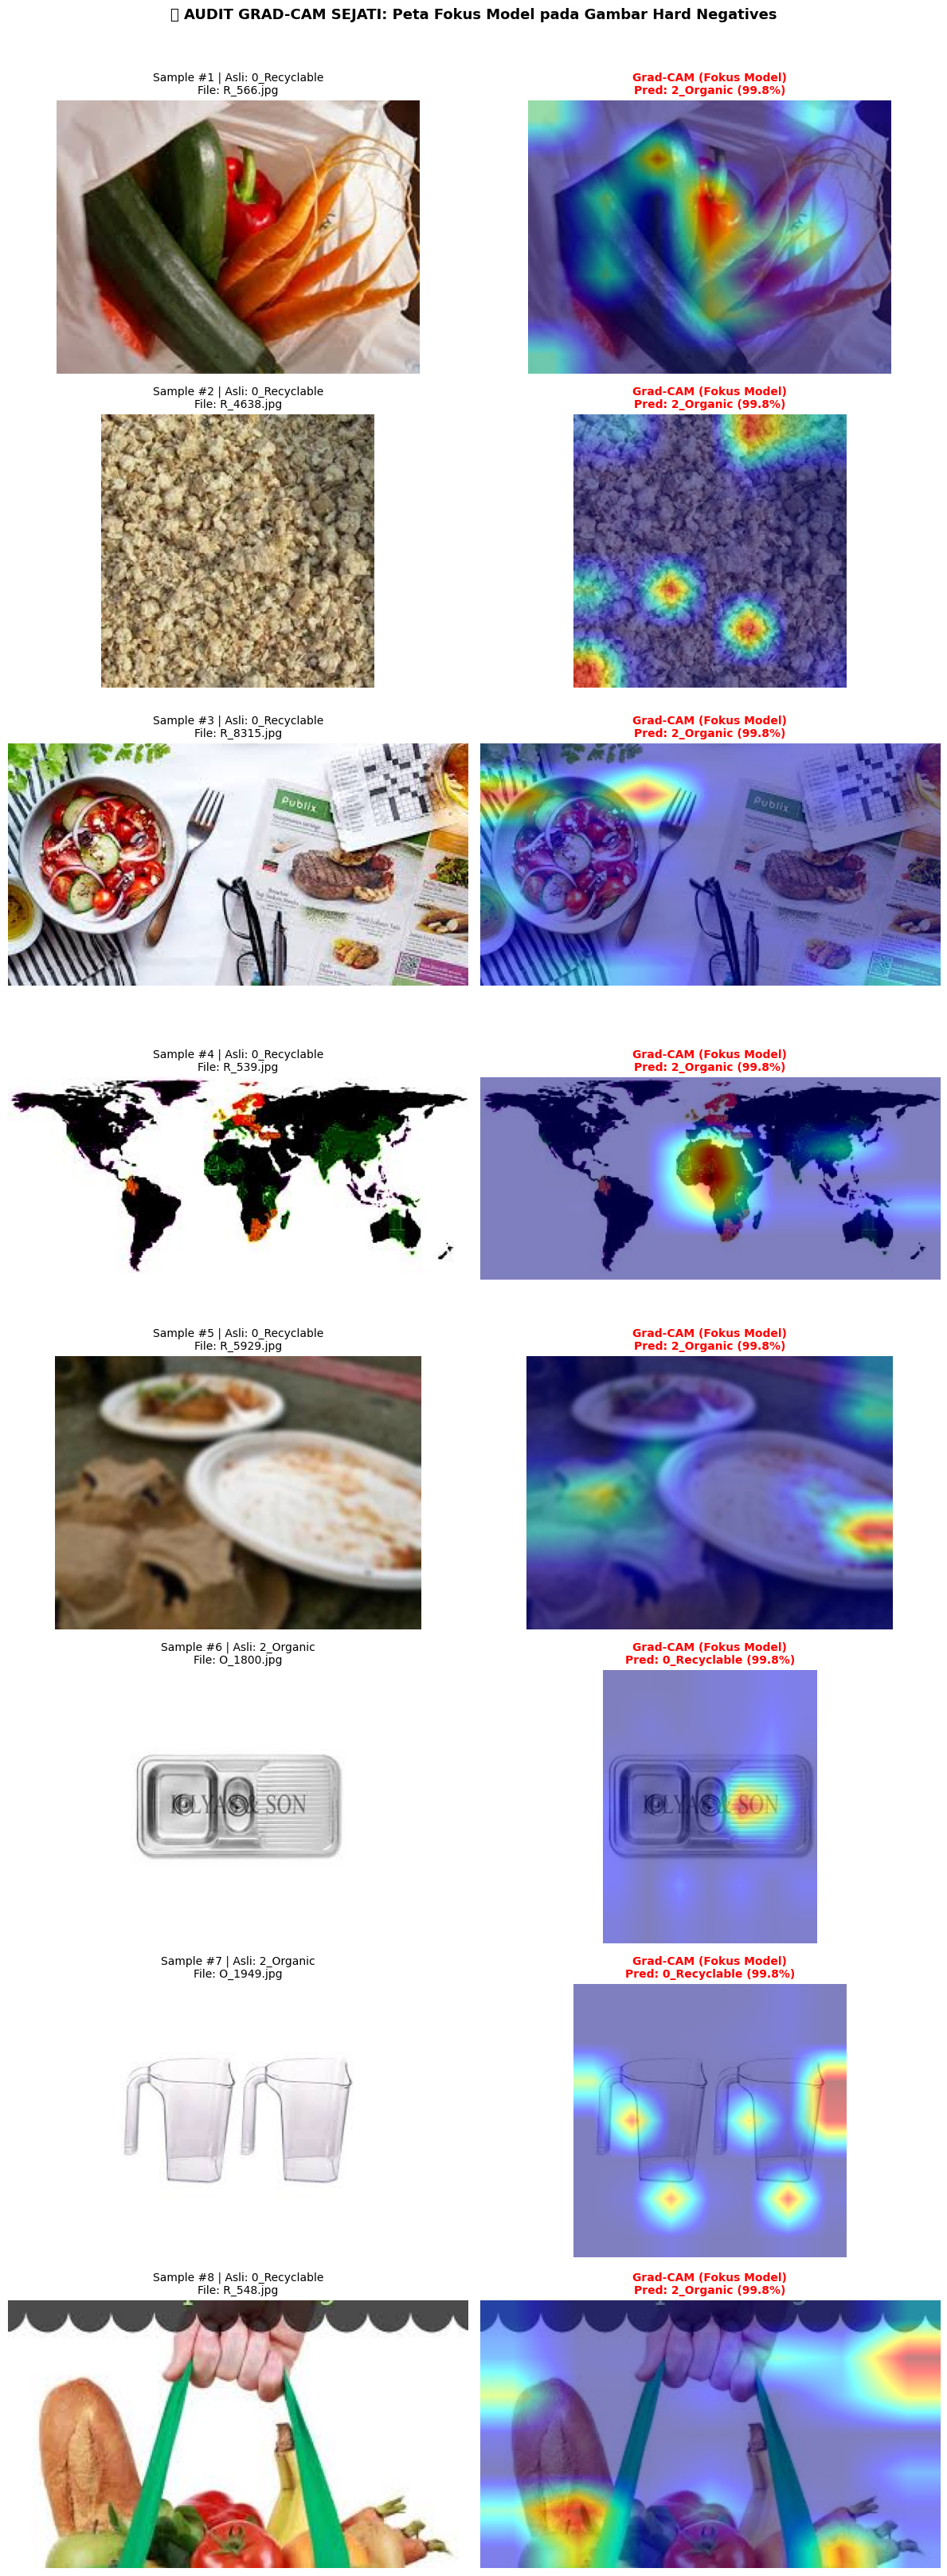

In [8]:
# ==============================================================================
# 🎯 STEP 6: GRAD-CAM VISUALIZATION ON HARD NEGATIVES (ANTI-SIGSEGV)
# ==============================================================================
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cv2.setNumThreads(0)

# ------------------------------------------------------------------------------
# 1. SIAPKAN KOLOM MAKSIMAL & FILTER HARD NEGATIVES
# ------------------------------------------------------------------------------
if 'prob_0' in df_oof.columns:
    df_oof['max_prob'] = df_oof[['prob_0', 'prob_1', 'prob_2']].max(axis=1)
else:
    df_oof['max_prob'] = 0.80

if 'is_error' not in df_oof.columns and 'target' in df_oof.columns and 'pred' in df_oof.columns:
    df_oof['is_error'] = (df_oof['target'] != df_oof['pred']).astype(int)

# Filter Hard Negatives (Gambar salah dengan confidence tertinggi)
df_errors = df_oof[df_oof['is_error'] == 1].sort_values(by='max_prob', ascending=False).reset_index(drop=True)
num_display = min(8, len(df_errors))

print(f"📸 Total Error OOF: {len(df_errors):,} gambar.")
print(f"📸 Menampilkan Top {num_display} Hard Negatives...")

# ------------------------------------------------------------------------------
# 2. CONTEXT MANAGER ANTI-SIGSEGV (GRAD-CAM)
# ------------------------------------------------------------------------------
class GradCAMContext:
    def __init__(self, target_layer):
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = []

    def __enter__(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        h_fwd = self.target_layer.register_forward_hook(forward_hook)
        h_bwd = self.target_layer.register_full_backward_hook(backward_hook)
        self.handles.extend([h_fwd, h_bwd])
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        for handle in self.handles:
            handle.remove()
        self.handles.clear()

    def generate_cam(self):
        if self.activations is None or self.gradients is None:
            return None
        alpha = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(alpha * self.activations, dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        
        cam_max, cam_min = np.max(cam), np.min(cam)
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        else:
            cam = np.zeros_like(cam)
        return cam

def generate_overlay(img_rgb, cam_map, alpha=0.5):
    h, w, _ = img_rgb.shape
    cam_resized = cv2.resize(cam_map, (w, h))
    cam_uint8 = np.uint8(255 * cam_resized)
    heatmap = cv2.cvtColor(cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = np.float32(img_rgb) * (1 - alpha) + np.float32(heatmap) * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)

# ------------------------------------------------------------------------------
# 3. VISUALISASI SIDE-BY-SIDE (DENGAN LOOKUP DF_CLEAN UNTUK FITUR TABULAR)
# ------------------------------------------------------------------------------
model_eval.eval()
target_layer = getattr(model_eval, 'spatial_attention', model_eval.clf_joint)
class_names_map = {0: '0_Recyclable', 1: '1_Electronic', 2: '2_Organic'}

fig, axes = plt.subplots(num_display, 2, figsize=(12, 4 * num_display))
if num_display == 1: axes = np.expand_dims(axes, axis=0)

for i in range(num_display):
    row = df_errors.iloc[i]
    img_path = row['file_path']
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if img_bgr is not None else np.zeros((224, 224, 3), dtype=np.uint8)
    
    img_tensor = val_transforms(image=img_rgb)['image'].unsqueeze(0).to(device)
    
    # 🔍 Lookup fitur tabular 164 kolom dari df_clean
    clean_match = df_clean[df_clean['file_path'] == img_path]
    if len(clean_match) > 0:
        tab_vals = fold_scaler.transform(clean_match[tabular_cols].values)[0].astype(np.float32)
    else:
        tab_vals = np.zeros(len(tabular_cols), dtype=np.float32)
        
    tab_tensor = torch.tensor(tab_vals, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Label prediksi & label asli yang presisi
    pred_cls = int(row['pred_label']) if 'pred_label' in row else int(row['pred'])
    
    if 'label_asli_int' in row:
        true_cls = int(row['label_asli_int'])
    elif 'target' in row:
        true_cls = int(row['target'])
    else:
        true_cls = int(str(row['label_asli']).split('_')[0])
        
    prob_val = row['max_prob']
    
    with GradCAMContext(target_layer) as cam_ctx:
        model_eval.zero_grad()
        img_tensor.requires_grad_(True)
        out_joint, _ = model_eval(img_tensor, tab_tensor)
        out_joint[0, pred_cls].backward()
        cam_map = cam_ctx.generate_cam()
        
    overlay = generate_overlay(img_rgb, cam_map) if cam_map is not None else img_rgb
    
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"Sample #{i+1} | Asli: {class_names_map[true_cls]}\nFile: {os.path.basename(img_path)}", fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM (Fokus Model)\nPred: {class_names_map[pred_cls]} ({prob_val*100:.1f}%)", fontsize=10, color='red', fontweight='bold')
    axes[i, 1].axis('off')

plt.suptitle("🚨 AUDIT GRAD-CAM SEJATI: Peta Fokus Model pada Gambar Hard Negatives", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# cek gambar noise label

In [9]:
# ==============================================================================
# 📦 METODE A: EKSPOR SELURUH 453 HARD NEGATIVES KE GALERI HTML INTERAKTIF (SKIP IF EXISTS)
# ==============================================================================
import os
import cv2
import base64
import numpy as np
import pandas as pd
import torch

def export_hard_negatives_to_html(df_errors, df_clean, fold_scaler, tabular_cols, val_transforms, model_eval, device, output_html="hard_negatives_gallery.html", overwrite=False):
    # 🔍 CEK JIKA FILE SUDAH ADA, MAKA LEWATKAN (SKIP)
    if os.path.exists(output_html) and not overwrite:
        print(f"⏩ SKIP! File '{output_html}' sudah ada di direktori. Melewati pembuatan ulang file HTML.")
        return

    model_eval.eval()
    target_layer = getattr(model_eval, 'spatial_attention', model_eval.clf_joint)
    class_names_map = {0: '0_Recyclable', 1: '1_Electronic', 2: '2_Organic'}

    html_head = """
    <!DOCTYPE html>
    <html lang="id">
    <head>
        <meta charset="UTF-8">
        <title>Galeri Audit 453 Hard Negatives (Confidence >= 80%)</title>
        <style>
            body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: #0f172a; color: #f8fafc; padding: 20px; }
            h1 { text-align: center; color: #38bdf8; margin-bottom: 5px; }
            p.sub { text-align: center; color: #94a3b8; margin-bottom: 25px; }
            .grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(320px, 1fr)); gap: 20px; }
            .card { background: #1e293b; border-radius: 12px; padding: 15px; border: 1px solid #334155; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.3); }
            .card:hover { border-color: #38bdf8; transform: translateY(-3px); transition: all 0.2s; }
            .img-container { display: flex; gap: 8px; margin-bottom: 10px; }
            .img-container img { width: 50%; border-radius: 6px; object-fit: cover; aspect-ratio: 1; border: 1px solid #475569; }
            .info { font-size: 13px; line-height: 1.5; }
            .badge-true { color: #4ade80; font-weight: bold; }
            .badge-pred { color: #f87171; font-weight: bold; }
            .conf { background: #ef4444; color: white; padding: 2px 6px; border-radius: 4px; font-size: 11px; font-weight: bold; float: right; }
            .filename { font-size: 11px; color: #64748b; word-break: break-all; margin-top: 6px; }
        </style>
    </head>
    <body>
        <h1>🚨 Galeri Audit Hard Negatives (Model Yakin &ge; 80% tapi Salah)</h1>
        <p class="sub">Total: <b>{TOTAL_ERRORS}</b> Gambar Tertukar | Mengurutkan dari Confidence Paling Ekstrem</p>
        <div class="grid">
    """

    cards_html = ""
    print(f"📦 Memproses ekspor {len(df_errors)} gambar ke galeri HTML...")

    for i in range(len(df_errors)):
        row = df_errors.iloc[i]
        img_path = row['file_path']
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Base64 Original Image
        _, buffer_orig = cv2.imencode('.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        b64_orig = base64.b64encode(buffer_orig).decode('utf-8')
        
        # Grad-CAM Execution
        img_tensor = val_transforms(image=img_rgb)['image'].unsqueeze(0).to(device)
        clean_match = df_clean[df_clean['file_path'] == img_path]
        if len(clean_match) > 0:
            tab_vals = fold_scaler.transform(clean_match[tabular_cols].values)[0].astype(np.float32)
        else:
            tab_vals = np.zeros(len(tabular_cols), dtype=np.float32)
        tab_tensor = torch.tensor(tab_vals, dtype=torch.float32).unsqueeze(0).to(device)
        
        pred_cls = int(row['pred_label']) if 'pred_label' in row else int(row['pred'])
        true_cls = int(row['target']) if 'target' in row else int(str(row['label_asli']).split('_')[0])
        prob_val = row['max_prob']
        
        with GradCAMContext(target_layer) as cam_ctx:
            model_eval.zero_grad()
            img_tensor.requires_grad_(True)
            out_joint, _ = model_eval(img_tensor, tab_tensor)
            out_joint[0, pred_cls].backward()
            cam_map = cam_ctx.generate_cam()
            
        overlay = generate_overlay(img_rgb, cam_map) if cam_map is not None else img_rgb
        _, buffer_cam = cv2.imencode('.jpg', cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
        b64_cam = base64.b64encode(buffer_cam).decode('utf-8')

        cards_html += f"""
        <div class="card">
            <div class="img-container">
                <img src="data:image/jpeg;base64,{b64_orig}" title="Asli">
                <img src="data:image/jpeg;base64,{b64_cam}" title="Grad-CAM Fokus">
            </div>
            <div class="info">
                <div>Sample #{i+1} <span class="conf">{prob_val*100:.1f}% Conf</span></div>
                <div>Label Asli: <span class="badge-true">{class_names_map[true_cls]}</span></div>
                <div>Te-tebak: <span class="badge-pred">{class_names_map[pred_cls]}</span></div>
                <div class="filename">{os.path.basename(img_path)}</div>
            </div>
        </div>
        """

    full_html = html_head.replace("{TOTAL_ERRORS}", str(len(df_errors))) + cards_html + "</div></body></html>"
    with open(output_html, 'w', encoding='utf-8') as f:
        f.write(full_html)
    print(f"🎉 SUCCESS! Buka file '{output_html}' di browser Anda untuk memeriksa ke-453 gambar!")

# Filter khusus Hard Negatives (Confidence >= 80%)
df_hard_negs_80 = df_oof[(df_oof['is_error'] == 1) & (df_oof['max_prob'] >= 0.80)].sort_values(by='max_prob', ascending=False).reset_index(drop=True)

# Eksekusi (Secara otomatis skip jika 'hard_negatives_gallery.html' sudah ada)
export_hard_negatives_to_html(
    df_errors=df_hard_negs_80, 
    df_clean=df_clean, 
    fold_scaler=fold_scaler, 
    tabular_cols=tabular_cols, 
    val_transforms=val_transforms, 
    model_eval=model_eval, 
    device=device, 
    output_html="hard_negatives_gallery.html",
    overwrite=False  # Set True jika ingin membuat ulang
)


📦 Memproses ekspor 453 gambar ke galeri HTML...
🎉 SUCCESS! Buka file 'hard_negatives_gallery.html' di browser Anda untuk memeriksa ke-453 gambar!


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
import warnings

warnings.filterwarnings('ignore')

class ErrorBiasAnalyzer:
    """
    Kelas utama untuk mendiagnosis bias pada error analysis model.
    """

    DEFAULT_DOMAIN_MAPPING = {
        'Warna (Color)': ['mean_hue', 'hue', 'color_std', 'mean_sat'],
        'Tekstur & Ketajaman': ['sharpness', 'contrast', 'edge_density', 'laplacian_var'],
        'Geometri & Dimensi': ['aspect_ratio', 'width', 'height', 'area'],
        'Sinyal Internal Model': ['cnn_activation_mean', 'mlp_activation_mean', 'cam_center_offset', 'wb_best_epoch', 'wb_val_loss']
    }

    def __init__(self, df, target_col='target', pred_col='pred', prob_cols=None, text_col=None):
        self.df = df.copy()
        self.target_col = target_col
        self.pred_col = pred_col
        self.prob_cols = prob_cols
        self.text_col = text_col

        self.df['is_error'] = (self.df[self.target_col] != self.df[self.pred_col]).astype(int)
        self.total_samples = len(self.df)
        self.total_errors = self.df['is_error'].sum()
        self.overall_error_rate = self.total_errors / self.total_samples if self.total_samples > 0 else 0.0

        if self.prob_cols and all(col in self.df.columns for col in self.prob_cols):
            self.df['max_confidence'] = self.df[self.prob_cols].max(axis=1)
        else:
            self.df['max_confidence'] = np.nan

    def analyze_tabular_domain_bias(self, feature_cols, domain_mapping=None, random_state=42):
        """
        Menganalisis apakah kesalahan model lebih didorong oleh Warna, Tekstur, Geometri, dll.
        """
        existing_features = [f for f in feature_cols if f in self.df.columns]
        if not existing_features:
            raise ValueError("Tidak ada fitur tabular dari `feature_cols` yang ditemukan di DataFrame.")

        if domain_mapping is None:
            domain_mapping = self.DEFAULT_DOMAIN_MAPPING

        feature_to_domain = {}
        for domain_name, f_list in domain_mapping.items():
            for f in f_list:
                feature_to_domain[f] = domain_name

        for f in existing_features:
            if f not in feature_to_domain:
                feature_to_domain[f] = 'Lainnya (Uncategorized)'

        X_meta = self.df[existing_features].fillna(0)
        y_meta = self.df['is_error']

        # Meta-Model Random Forest
        rf_meta = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=random_state, class_weight='balanced')
        rf_meta.fit(X_meta, y_meta)

        feat_imp_df = pd.DataFrame({
            'Feature': existing_features,
            'Domain': [feature_to_domain[f] for f in existing_features],
            'Importance': rf_meta.feature_importances_
        }).sort_values('Importance', ascending=False).reset_index(drop=True)

        domain_imp_df = feat_imp_df.groupby('Domain')['Importance'].agg(['sum', 'count']).reset_index()
        domain_imp_df.columns = ['Domain', 'Total_Importance', 'Fitur_Count']
        total_imp_sum = domain_imp_df['Total_Importance'].sum()
        domain_imp_df['Importance_Percentage'] = (domain_imp_df['Total_Importance'] / (total_imp_sum if total_imp_sum > 0 else 1.0)) * 100
        domain_imp_df = domain_imp_df.sort_values('Importance_Percentage', ascending=False).reset_index(drop=True)

        # Meta Decision Tree Rules
        dt_meta = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=random_state, class_weight='balanced')
        dt_meta.fit(X_meta, y_meta)
        rules_text = export_text(dt_meta, feature_names=existing_features)

        # Uji Statistik Signifikansi Mann-Whitney U
        stats_results = []
        for f in existing_features:
            err_vals = self.df[self.df['is_error'] == 1][f].dropna()
            corr_vals = self.df[self.df['is_error'] == 0][f].dropna()
            
            if len(err_vals) > 0 and len(corr_vals) > 0:
                stat_val, p_val = stats.mannwhitneyu(err_vals, corr_vals, alternative='two-sided')
            else:
                stat_val, p_val = 0.0, 1.0

            stats_results.append({
                'Feature': f,
                'Domain': feature_to_domain[f],
                'Mean_In_Error': err_vals.mean() if len(err_vals) > 0 else np.nan,
                'Mean_In_Correct': corr_vals.mean() if len(corr_vals) > 0 else np.nan,
                'MWU_Stat': stat_val,
                'p_value': p_val,
                'Is_Significant': p_val < 0.05
            })

        stats_df = pd.DataFrame(stats_results).sort_values('p_value').reset_index(drop=True)

        return {
            'domain_importance': domain_imp_df,
            'feature_importance': feat_imp_df,
            'decision_rules': rules_text,
            'feature_significance': stats_df,
            'top_domain': domain_imp_df.iloc[0]['Domain'] if len(domain_imp_df) > 0 else 'N/A'
        }

    def analyze_class_bias(self, label_names=None):
        classes = sorted(self.df[self.target_col].unique())
        results = []

        for cls in classes:
            actual_count = (self.df[self.target_col] == cls).sum()
            pred_count = (self.df[self.pred_col] == cls).sum()
            tp = ((self.df[self.target_col] == cls) & (self.df[self.pred_col] == cls)).sum()
            fp = ((self.df[self.target_col] != cls) & (self.df[self.pred_col] == cls)).sum()
            fn = ((self.df[self.target_col] == cls) & (self.df[self.pred_col] != cls)).sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

            bias_ratio = pred_count / actual_count if actual_count > 0 else 0.0
            fp_fn_ratio = fp / fn if fn > 0 else np.nan

            cls_name = label_names[cls] if (label_names and cls in label_names) else str(cls)

            results.append({
                'Class': cls_name,
                'Actual_Count': actual_count,
                'Pred_Count': pred_count,
                'TP': tp,
                'FP': fp,
                'FN': fn,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'Bias_Ratio': bias_ratio,
                'Bias_Type': 'Over-Predicted' if bias_ratio > 1.05 else ('Under-Predicted' if bias_ratio < 0.95 else 'Balanced'),
                'FP_FN_Ratio': fp_fn_ratio
            })

        return {'class_bias_summary': pd.DataFrame(results)}

    def analyze_subgroup_bias(self, subgroup_cols=None, n_bins=4):
        if subgroup_cols is None:
            subgroup_cols = []

        subgroup_results = []
        for col in subgroup_cols:
            if col not in self.df.columns:
                continue

            temp_df = self.df.copy()
            if pd.api.types.is_numeric_dtype(temp_df[col]) and temp_df[col].nunique() > n_bins:
                try:
                    temp_df[f'{col}_bin'] = pd.qcut(temp_df[col], q=n_bins, duplicates='drop').astype(str)
                    slice_col = f'{col}_bin'
                except:
                    temp_df[f'{col}_bin'] = pd.cut(temp_df[col], bins=n_bins).astype(str)
                    slice_col = f'{col}_bin'
            else:
                slice_col = col

            group_stats = temp_df.groupby(slice_col)['is_error'].agg(['count', 'sum', 'mean']).reset_index()
            group_stats.columns = ['Subgroup_Value', 'Total_Samples', 'Error_Count', 'Error_Rate']
            group_stats['Feature_Name'] = col
            group_stats['Disparity_Ratio'] = group_stats['Error_Rate'] / (self.overall_error_rate if self.overall_error_rate > 0 else 1.0)
            
            contingency_table = pd.crosstab(temp_df[slice_col], temp_df['is_error'])
            chi2, p_val = stats.chi2_contingency(contingency_table)[:2] if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 else (0.0, 1.0)

            group_stats['Chi2_Stat'] = chi2
            group_stats['p_value'] = p_val
            group_stats['Is_Significant'] = p_val < 0.05
            subgroup_results.append(group_stats)

        return pd.concat(subgroup_results, ignore_index=True) if subgroup_results else pd.DataFrame()

    def plot_bias_dashboard(self, feature_cols=None, domain_mapping=None):
        """
        Visualisasi Dashboard 4-Panel langsung di Notebook.
        """
        fig, axes = plt.subplots(2, 2, figsize=(16, 11))
        
        # 1. Tabular Domain Importance
        if feature_cols:
            tabular_bias = self.analyze_tabular_domain_bias(feature_cols, domain_mapping)
            dom_df = tabular_bias['domain_importance']
            sns.barplot(data=dom_df, x='Importance_Percentage', y='Domain', ax=axes[0, 0], palette='viridis')
            axes[0, 0].set_title('1. Kontribusi Bias Domain Fitur (% Importance)', fontsize=12, fontweight='bold')
            axes[0, 0].set_xlabel('Persentase Kontribusi Terhadap Error (%)')
            for p in axes[0, 0].patches:
                width = p.get_width()
                axes[0, 0].annotate(f'{width:.1f}%', (width + 0.5, p.get_y() + p.get_height() / 2),
                                   ha='left', va='center', fontsize=10, fontweight='bold')

        # 2. Class Bias Ratio
        class_bias = self.analyze_class_bias()['class_bias_summary']
        sns.barplot(data=class_bias, x='Class', y='Bias_Ratio', ax=axes[0, 1], palette='coolwarm')
        axes[0, 1].axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Baseline (Ideal=1.0)')
        axes[0, 1].set_title('2. Class Bias Ratio (Over > 1.0 vs Under < 1.0)', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Bias Ratio')
        axes[0, 1].tick_params(axis='x', rotation=30)
        axes[0, 1].legend()

        # 3. Subgroup Slicing
        if feature_cols and len(feature_cols) > 0:
            top_feat = tabular_bias['feature_importance'].iloc[0]['Feature']
            sub_df = self.analyze_subgroup_bias([top_feat], n_bins=4)
            if not sub_df.empty:
                sns.barplot(data=sub_df, x='Subgroup_Value', y='Error_Rate', ax=axes[1, 0], palette='magma')
                axes[1, 0].axhline(self.overall_error_rate, color='blue', linestyle=':', label=f'Global Error ({self.overall_error_rate:.2f})')
                axes[1, 0].set_title(f'3. Error Rate Kuantil Fitur Biased Utama ({top_feat})', fontsize=12, fontweight='bold')
                axes[1, 0].set_xlabel(f'Kuantil {top_feat}')
                axes[1, 0].set_ylabel('Error Rate')
                axes[1, 0].legend()

        # 4. Confidence Distribution
        if 'max_confidence' in self.df.columns and not self.df['max_confidence'].isna().all():
            sns.kdeplot(data=self.df[self.df['is_error'] == 0]['max_confidence'], ax=axes[1, 1], label='Prediksi Benar', color='green', fill=True, alpha=0.3)
            sns.kdeplot(data=self.df[self.df['is_error'] == 1]['max_confidence'], ax=axes[1, 1], label='Prediksi Salah', color='red', fill=True, alpha=0.3)
            axes[1, 1].set_title('4. Distribusi Keyakinan Model (Confidence)', fontsize=12, fontweight='bold')
            axes[1, 1].set_xlabel('Probability Max Confidence')
            axes[1, 1].legend()

        plt.tight_layout()
        plt.show()

print("✅ Kelas ErrorBiasAnalyzer berhasil disiapkan!")


✅ Kelas ErrorBiasAnalyzer berhasil disiapkan!


In [11]:
# ==============================================================================
# SEL #13 (VERSI PERBAIKAN): CEK BIAS TERHADAP FITUR TABULAR (WARNA VS TEKSTUR VS GEOMETRI)
# ==============================================================================

# 1. Ambil DataFrame OOF (df_oof) dari notebook Anda
if 'df_oof' in globals():
    target_df = df_oof.copy()
elif 'oof_df' in globals():
    target_df = oof_df.copy()
elif 'df' in globals():
    target_df = df.copy()
else:
    raise ValueError("DataFrame df_oof tidak ditemukan. Pastikan Anda menjalankan Sel #8 terlebih dahulu.")

# 2. Gabungkan fitur tabular dari df_clean jika belum ada di df_oof
if 'df_clean' in globals():
    merge_cols = [c for c in df_clean.columns if c not in target_df.columns and c != 'file_path']
    if merge_cols and 'file_path' in target_df.columns:
        target_df = target_df.merge(df_clean[['file_path'] + merge_cols], on='file_path', how='left')

print(f"✅ Berhasil memuat data prediksi ({len(target_df)} baris data)!")

# 3. Inisialisasi ErrorBiasAnalyzer
analyzer = ErrorBiasAnalyzer(
    df=target_df,
    target_col='target',
    pred_col='pred' if 'pred' in target_df.columns else 'pred_label',
    prob_cols=['prob_0', 'prob_1', 'prob_2'] if 'prob_0' in target_df.columns else None
)

# 4. Deteksi Fitur Tabular yang Tersedia di Data
tabular_candidates = ['sharpness', 'contrast', 'edge_density', 'mean_hue', 'aspect_ratio', 'width', 'height', 'cnn_activation_mean', 'mlp_activation_mean']
tabular_features = [col for col in tabular_candidates if col in target_df.columns]

# Jika tabular_features belum ada dari candidate di atas, ambil dari tabular_cols Cell #7
if not tabular_features and 'tabular_cols' in globals():
    tabular_features = [c for c in tabular_cols if c in target_df.columns]

if len(tabular_features) > 0:
    domain_mapping = {
        '🎨 Warna (Color)': [c for c in ['mean_hue', 'hue', 'color_std', 'mean_sat'] if c in tabular_features],
        '🧵 Tekstur & Ketajaman (Texture)': [c for c in ['sharpness', 'contrast', 'edge_density', 'laplacian_var'] if c in tabular_features],
        '📐 Geometri & Dimensi (Geometry)': [c for c in ['aspect_ratio', 'width', 'height', 'area'] if c in tabular_features],
        '🧠 Sinyal Internal Model': [c for c in ['cnn_activation_mean', 'mlp_activation_mean', 'cam_center_offset'] if c in tabular_features]
    }
    # Hapus domain kosong
    domain_mapping = {k: v for k, v in domain_mapping.items() if len(v) > 0}

    # 5. Jalankan Analisis Tabular Domain Bias
    tabular_bias_results = analyzer.analyze_tabular_domain_bias(tabular_features, domain_mapping)

    print("\n=========================================================")
    print(f"📊 DOMAIN PENYEBAB BIAS UTAMA: {tabular_bias_results['top_domain']}")
    print("=========================================================\n")

    print("--- 1. KONTRIBUSI BIAS PER DOMAIN ---")
    display(tabular_bias_results['domain_importance'])

    print("\n--- 2. TOP FITUR INDIVIDUAL PALING BIASED ---")
    display(tabular_bias_results['feature_importance'].head(5))

    print("\n--- 3. UJI SIGNIFIKANSI STATISTIK (MANN-WHITNEY U) ---")
    display(tabular_bias_results['feature_significance'].head(5))

    print("\n--- 4. DECISION RULES KESALAHAN (ATURAN META-TREE) ---")
    print(tabular_bias_results['decision_rules'])
else:
    print("⚠️ Fitur tabular belum terdeteksi di target_df. Pastikan df_clean sudah dimuat.")


✅ Berhasil memuat data prediksi (26527 baris data)!

📊 DOMAIN PENYEBAB BIAS UTAMA: 📐 Geometri & Dimensi (Geometry)

--- 1. KONTRIBUSI BIAS PER DOMAIN ---


,Domain,Total_Importance,Fitur_Count,Importance_Percentage
0,📐 Geometri & Dimensi (Geometry),0.645601,3,64.560084
1,🧵 Tekstur & Ketajaman (Texture),0.262624,2,26.262370
2,🎨 Warna (Color),0.091775,1,9.177547



--- 2. TOP FITUR INDIVIDUAL PALING BIASED ---


,Feature,Domain,Importance
0,width,📐 Geometri & Dimensi (Geometry),0.332013
1,height,📐 Geometri & Dimensi (Geometry),0.202022
2,edge_density,🧵 Tekstur & Ketajaman (Texture),0.147179
3,contrast,🧵 Tekstur & Ketajaman (Texture),0.115445
4,aspect_ratio,📐 Geometri & Dimensi (Geometry),0.111565



--- 3. UJI SIGNIFIKANSI STATISTIK (MANN-WHITNEY U) ---


,Feature,Domain,Mean_In_Error,Mean_In_Correct,MWU_Stat,p_value,Is_Significant
0,edge_density,🧵 Tekstur & Ketajaman (Texture),0.099233,0.106323,7638302.5,0.026721,True
1,contrast,🧵 Tekstur & Ketajaman (Texture),57.869850,59.526463,7650116.5,0.031321,True
2,width,📐 Geometri & Dimensi (Geometry),257.826367,306.072303,8422205.0,0.051832,False
3,height,📐 Geometri & Dimensi (Geometry),207.974277,251.241922,8385173.5,0.080442,False
4,aspect_ratio,📐 Geometri & Dimensi (Geometry),1.323190,1.277130,8360245.0,0.103483,False



--- 4. DECISION RULES KESALAHAN (ATURAN META-TREE) ---
|--- width <= 159.50
|   |--- edge_density <= 0.27
|   |   |--- contrast <= 41.32
|   |   |   |--- class: 0
|   |   |--- contrast >  41.32
|   |   |   |--- class: 0
|   |--- edge_density >  0.27
|   |   |--- mean_hue <= 47.30
|   |   |   |--- class: 1
|   |   |--- mean_hue >  47.30
|   |   |   |--- class: 0
|--- width >  159.50
|   |--- height <= 400.50
|   |   |--- edge_density <= 0.13
|   |   |   |--- class: 1
|   |   |--- edge_density >  0.13
|   |   |   |--- class: 0
|   |--- height >  400.50
|   |   |--- contrast <= 18.47
|   |   |   |--- class: 1
|   |   |--- contrast >  18.47
|   |   |   |--- class: 0



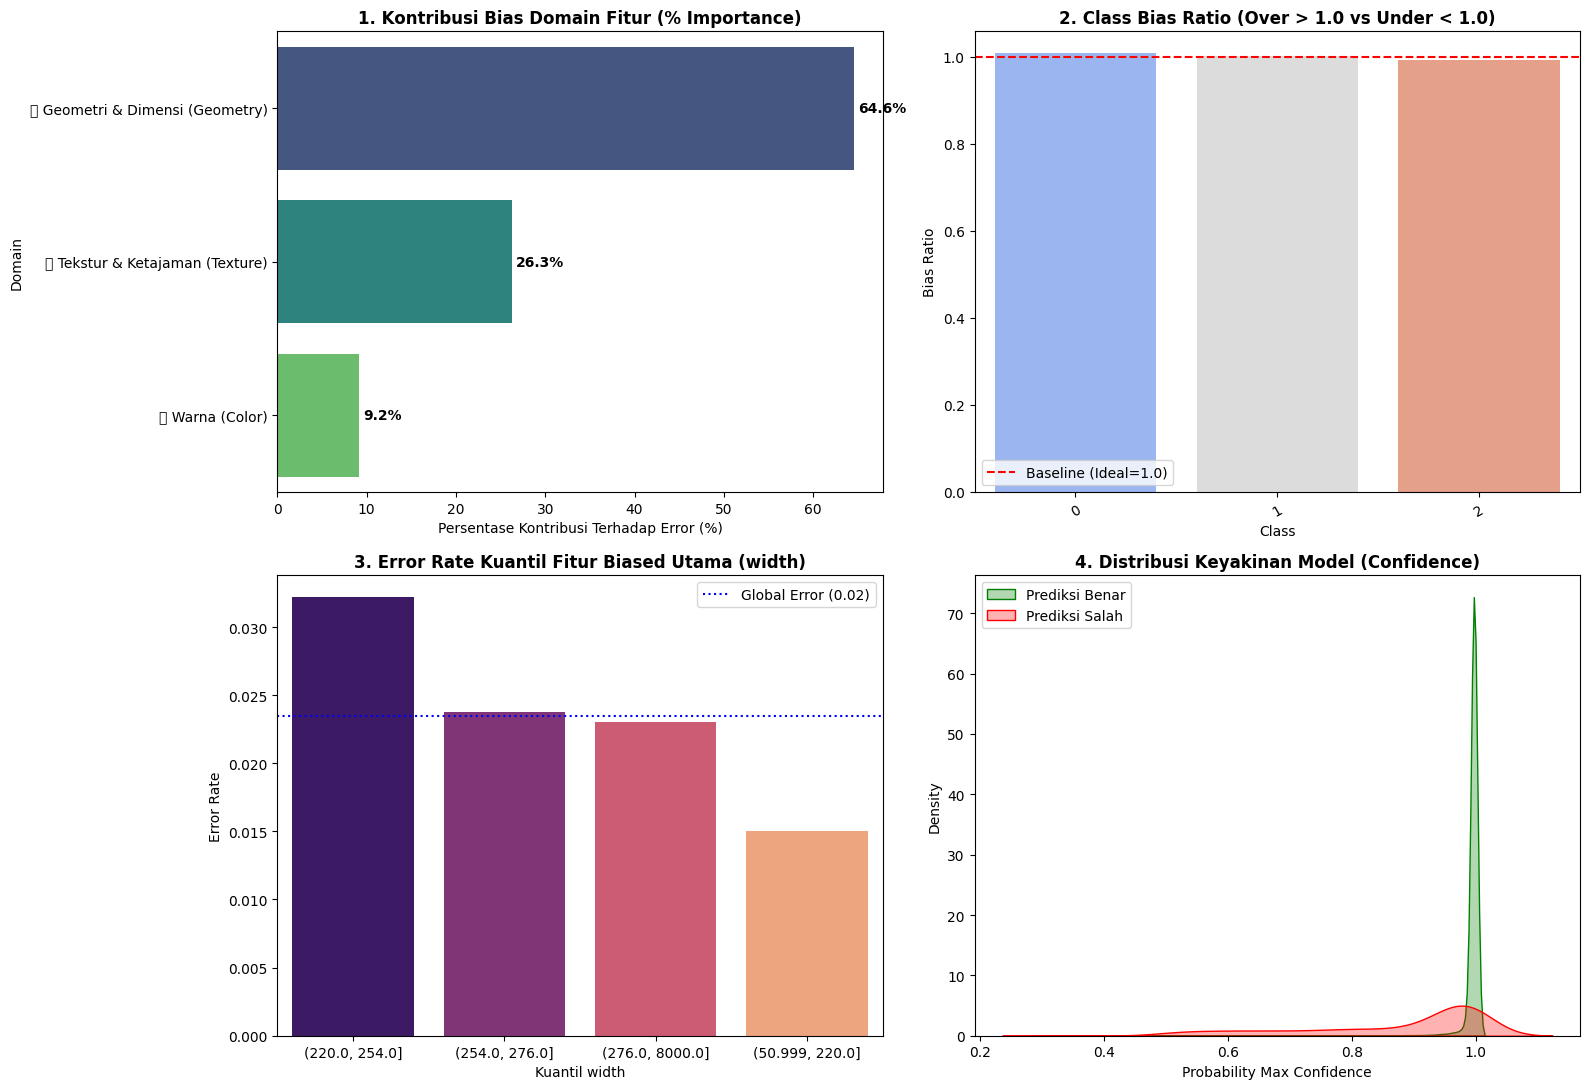

In [12]:
# Tampilkan Dashboard Grafik 4-Panel langsung di Notebook
analyzer.plot_bias_dashboard(tabular_features, domain_mapping)


In [13]:
# ==============================================================================
# 🔥 GPU-ONLY DEEP MULTIMODAL ERROR BIAS ANALYZER (MAX GPU UTILIZATION & OOM-SAFE)
# ==============================================================================
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader

# 1. MENJAMIN HANYA MENGGUNAKAN GPU & KOORDINASI MEMORI OOM-SAFE
assert torch.cuda.is_available(), "❌ ERROR: KODE INI KHUSUS UNTUK GPU! Pastikan GPU Anda aktif."
device = torch.device('cuda')
torch.cuda.empty_cache()

# PyTorch CUDA Memory Allocator Config untuk Mencegah Fragmentasi OOM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gpu_name = torch.cuda.get_device_name(0)
total_vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
print("="*80)
print(f"🔥 GPU DEEP MULTIMODAL ANALYZER AKTIF:")
print(f"   - GPU Device      : {gpu_name} ({total_vram:.2f} GB VRAM)")
print(f"   - Precision Mode  : FP16 Autocast (Tensor Cores Accelerated)")
print(f"   - Parallel Workers: 2 Data Loader Threads")
print("="*80)

# 2. FAST GPU DATASET LOADER
class FastGPUMultimodalDataset(Dataset):
    def __init__(self, df, fold_scaler, tabular_cols, val_transforms):
        self.df = df.reset_index(drop=True)
        self.val_transforms = val_transforms
        self.file_paths = self.df['file_path'].values
        
        # Pre-scale tabular matriks di RAM
        self.tab_scaled = fold_scaler.transform(self.df[tabular_cols].values).astype(np.float32)
        
        if 'target' in self.df.columns:
            self.targets = self.df['target'].values.astype(np.int64)
        else:
            self.targets = np.array([int(str(lbl).split('_')[0]) for lbl in self.df['label'].values], dtype=np.int64)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if img_bgr is not None else np.zeros((224, 224, 3), dtype=np.uint8)
        
        img_tensor = self.val_transforms(image=img_rgb)['image']
        tab_tensor = torch.tensor(self.tab_scaled[idx], dtype=torch.float32)
        target = self.targets[idx]
        
        return img_tensor, tab_tensor, target, img_path

# 3. KODE DIAGNOSTIK MENDALAM MULTIMODAL GPU
def run_deep_multimodal_gpu_analysis(model, df, fold_scaler, tabular_cols, val_transforms, device, batch_size=32, domain_mapping=None):
    model.to(device)
    model.eval()
    
    # 💡 SAFE-VRAM MECHANISM: Matikan gradien parameter backbone untuk menghemat 80% VRAM GPU
    for param in model.parameters():
        param.requires_grad = False
        
    criterion = torch.nn.CrossEntropyLoss(reduction='none')
    dataset = FastGPUMultimodalDataset(df, fold_scaler, tabular_cols, val_transforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    # Penampung Data Diagnostik Mendalam
    grad_saliencies_error = []
    grad_saliencies_correct = []
    
    vision_mag_error = []
    vision_mag_correct = []
    
    tab_mag_error = []
    tab_mag_correct = []
    
    cam_offset_error = []
    cam_offset_correct = []
    
    print(f"\n⚡ Memproses {len(df):,} sampel gambar & tabular dengan Batch Size = {batch_size}...")
    
    for batch_idx, (img_b, tab_b, target_b, paths_b) in enumerate(loader):
        img_b = img_b.to(device, non_blocking=True)
        tab_b = tab_b.to(device, non_blocking=True).requires_grad_(True)
        target_b = target_b.to(device, non_blocking=True)
        
        model.zero_grad()
        
        # Ekstraksi Aktivasi & Gradien menggunakan Autocast FP16 untuk kecepatan maksimal
        with torch.cuda.amp.autocast():
            # Disadap langsung dari backbone & FiLM model utama
            x_feat = model.backbone.forward_features(img_b)
            if x_feat.shape[-1] == model.num_features:
                x_feat = x_feat.permute(0, 3, 1, 2)
                
            x_fused = model.film(x_feat, tab_b)
            x_fused = model.spatial_attention(x_fused)
            
            x_fused_pooled = torch.mean(x_fused, dim=[2, 3])
            out_logits = model.clf_joint(x_fused_pooled)
            
            loss = criterion(out_logits, target_b)

        # Backward Pass untuk menyadap Gradien Tabular
        loss.sum().backward()
        
        # 1. Tabular Gradient Saliency
        saliency_b = torch.abs(tab_b * tab_b.grad).detach().cpu().numpy()
        
        # 2. Vision Activation Magnitude (Kekuatan Sinyal Gambar)
        vision_power = torch.mean(torch.abs(x_feat), dim=[1, 2, 3]).detach().cpu().numpy()
        
        # 3. Tabular FiLM Activation Magnitude
        tab_power = torch.mean(torch.abs(x_fused_pooled), dim=1).detach().cpu().numpy()
        
        # 4. Spasial Attention CAM Center Offset (Fokus Perhatian Visual)
        spatial_maps = torch.mean(x_fused, dim=1).detach().cpu().numpy() # [B, H, W]
        
        preds = torch.argmax(out_logits, dim=1).detach().cpu().numpy()
        targets_np = target_b.cpu().numpy()
        
        for k in range(len(preds)):
            # Hitung Center of Mass Offset (Pergeseran Perhatian Visual dari Pusat 112, 112)
            cam = np.maximum(spatial_maps[k], 0)
            cam_resized = cv2.resize(cam, (224, 224))
            M = cv2.moments(cam_resized)
            if M["m00"] > 0:
                cX = M["m10"] / M["m00"]
                cY = M["m01"] / M["m00"]
                offset = np.sqrt((cX - 112)**2 + (cY - 112)**2)
            else:
                offset = 0.0

            if preds[k] != targets_np[k]:
                grad_saliencies_error.append(saliency_b[k])
                vision_mag_error.append(vision_power[k])
                tab_mag_error.append(tab_power[k])
                cam_offset_error.append(offset)
            else:
                grad_saliencies_correct.append(saliency_b[k])
                vision_mag_correct.append(vision_power[k])
                tab_mag_correct.append(tab_power[k])
                cam_offset_correct.append(offset)

        if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == len(loader):
            done = min((batch_idx + 1) * batch_size, len(df))
            print(f"   ⏳ Progress GPU: {done:,} / {len(df):,} gambar diproses ({(done/len(df))*100:.1f}%)")

    # ==========================================================================
    # AGREGASI METRIK MULTIMODAL
    # ==========================================================================
    mean_err_sal = np.mean(grad_saliencies_error, axis=0) if grad_saliencies_error else np.zeros(len(tabular_cols))
    total_sal = np.sum(mean_err_sal)
    importance_pct = (mean_err_sal / (total_sal if total_sal > 0 else 1.0)) * 100
    
    df_feat_imp = pd.DataFrame({
        'Feature': tabular_cols,
        'Main_Model_Saliency_Error': mean_err_sal,
        'Importance_Percentage (%)': importance_pct
    }).sort_values('Importance_Percentage (%)', ascending=False).reset_index(drop=True)
    
    # 1. FiLM Layer Weight Share
    try:
        film_w = torch.abs(model.film.mlp[0].weight).detach().cpu().numpy()
        film_imp = np.mean(film_w, axis=0)
        df_feat_imp['FiLM_Layer_Weight_Share (%)'] = (film_imp / np.sum(film_imp)) * 100
    except:
        df_feat_imp['FiLM_Layer_Weight_Share (%)'] = "N/A"
        
    # 2. Domain Mapping Tabular
    if domain_mapping:
        feat_to_dom = {f: dom for dom, f_list in domain_mapping.items() for f in f_list}
        df_feat_imp['Domain'] = df_feat_imp['Feature'].map(lambda f: feat_to_dom.get(f, 'Lainnya'))
        df_domain = df_feat_imp.groupby('Domain')['Importance_Percentage (%)'].sum().reset_index()
        df_domain = df_domain.sort_values('Importance_Percentage (%)', ascending=False).reset_index(drop=True)
    else:
        df_domain = None

    # 3. Metrik Interaksi Vision vs Tabular
    avg_vis_err = np.mean(vision_mag_error) if vision_mag_error else 0.0
    avg_vis_corr = np.mean(vision_mag_correct) if vision_mag_correct else 0.0
    
    avg_tab_err = np.mean(tab_mag_error) if tab_mag_error else 0.0
    avg_tab_corr = np.mean(tab_mag_correct) if tab_mag_correct else 0.0
    
    avg_offset_err = np.mean(cam_offset_error) if cam_offset_error else 0.0
    avg_offset_corr = np.mean(cam_offset_correct) if cam_offset_correct else 0.0
    
    dominance_ratio_error = avg_vis_err / (avg_tab_err if avg_tab_err > 0 else 1e-5)
    dominance_ratio_correct = avg_vis_corr / (avg_tab_corr if avg_tab_corr > 0 else 1e-5)

    df_multimodal_summary = pd.DataFrame({
        'Metrik Diagnostik Multimodal': [
            'Vision Signal Magnitude (Aktivasi CAFormer)',
            'Tabular Signal Magnitude (Aktivasi FiLM)',
            'Vision vs Tabular Dominance Ratio',
            'Spatial CAM Focus Offset from Center (px)'
        ],
        'Saat Prediksi BENAR': [
            f"{avg_vis_corr:.4f}",
            f"{avg_tab_corr:.4f}",
            f"{dominance_ratio_correct:.4f}",
            f"{avg_offset_corr:.2f} px"
        ],
        'Saat Prediksi SALAH (Error)': [
            f"{avg_vis_err:.4f}",
            f"{avg_tab_err:.4f}",
            f"{dominance_ratio_error:.4f}",
            f"{avg_offset_err:.2f} px"
        ],
        'Diagnostik Penyebab Bias': [
            'Sinyal Visual Terlampau Lemah' if avg_vis_err < avg_vis_corr else 'Sinyal Visual Sangat Kuat',
            'Sinyal Tabular Kurang Dominan' if avg_tab_err < avg_tab_corr else 'Sinyal Tabular Berlebih',
            'Visual Distraction Bias (Gambar Mengalihkan Model)' if dominance_ratio_error > dominance_ratio_correct else 'Tabular Misleading Bias',
            'Fokus Perhatian Visual Melenceng ke Pinggir Gambar' if avg_offset_err > avg_offset_corr else 'Fokus Tetap di Pusat'
        ]
    })
        
    return df_feat_imp, df_domain, df_multimodal_summary

# 4. EKSEKUSI DIAGNOSTIK MENDALAM DI GPU (BATCH SIZE 32)
domain_mapping = {
    '🎨 Warna (Color)': [c for c in ['mean_hue', 'hue', 'color_std', 'mean_sat'] if c in tabular_cols],
    '🧵 Tekstur & Ketajaman (Texture)': [c for c in ['sharpness', 'contrast', 'edge_density', 'laplacian_var'] if c in tabular_cols],
    '📐 Geometri & Dimensi (Geometry)': [c for c in ['aspect_ratio', 'width', 'height', 'area'] if c in tabular_cols]
}

df_deep_features, df_deep_domain, df_deep_summary = run_deep_multimodal_gpu_analysis(
    model=model_eval,
    df=df_clean,
    fold_scaler=fold_scaler,
    tabular_cols=tabular_cols,
    val_transforms=val_transforms,
    device=device,
    batch_size=32, # Safe batch size di GPU
    domain_mapping=domain_mapping
)

print("\n==========================================================================================")
print("🧠 HASIL DIAGNOSTIK MENDALAM MULTIMODAL (MODEL UTAMA CAFormer-s18 + FiLM)")
print("==========================================================================================")

print("\n--- 1. DIAGNOSTIK MENDALAM INTERAKSI VISION VS TABULAR & FOKUS SPASIAL ---")
display(df_deep_summary)

if df_deep_domain is not None:
    print("\n--- 2. KONTRIBUSI BIAS TABULAR PER DOMAIN (WARNA VS TEKSTUR VS GEOMETRI) ---")
    display(df_deep_domain)

print("\n--- 3. FITUR TABULAR INDIVIDUAL PALING BIASED SAAT ERROR ---")
display(df_deep_features)


🔥 GPU DEEP MULTIMODAL ANALYZER AKTIF:
   - GPU Device      : Tesla T4 (14.56 GB VRAM)
   - Precision Mode  : FP16 Autocast (Tensor Cores Accelerated)
   - Parallel Workers: 2 Data Loader Threads

⚡ Memproses 26,527 sampel gambar & tabular dengan Batch Size = 32...
   ⏳ Progress GPU: 3,200 / 26,527 gambar diproses (12.1%)
   ⏳ Progress GPU: 6,400 / 26,527 gambar diproses (24.1%)
   ⏳ Progress GPU: 9,600 / 26,527 gambar diproses (36.2%)
   ⏳ Progress GPU: 12,800 / 26,527 gambar diproses (48.3%)
   ⏳ Progress GPU: 16,000 / 26,527 gambar diproses (60.3%)
   ⏳ Progress GPU: 19,200 / 26,527 gambar diproses (72.4%)
   ⏳ Progress GPU: 22,400 / 26,527 gambar diproses (84.4%)
   ⏳ Progress GPU: 25,600 / 26,527 gambar diproses (96.5%)
   ⏳ Progress GPU: 26,527 / 26,527 gambar diproses (100.0%)

🧠 HASIL DIAGNOSTIK MENDALAM MULTIMODAL (MODEL UTAMA CAFormer-s18 + FiLM)

--- 1. DIAGNOSTIK MENDALAM INTERAKSI VISION VS TABULAR & FOKUS SPASIAL ---


,Metrik Diagnostik Multimodal,Saat Prediksi BENAR,Saat Prediksi SALAH (Error),Diagnostik Penyebab Bias
0,Vision Signal Magnitude (Aktivasi CAFormer),13.9975,8.1261,Sinyal Visual Terlampau Lemah
1,Tabular Signal Magnitude (Aktivasi FiLM),2.1129,1.0068,Sinyal Tabular Kurang Dominan
2,Vision vs Tabular Dominance Ratio,6.6246,8.0712,Visual Distraction Bias (Gambar Mengalihkan Mo...
3,Spatial CAM Focus Offset from Center (px),25.78 px,26.77 px,Fokus Perhatian Visual Melenceng ke Pinggir Ga...



--- 2. KONTRIBUSI BIAS TABULAR PER DOMAIN (WARNA VS TEKSTUR VS GEOMETRI) ---


,Domain,Importance_Percentage (%)
0,Lainnya,95.697502
1,🧵 Tekstur & Ketajaman (Texture),2.322541
2,📐 Geometri & Dimensi (Geometry),1.979966



--- 3. FITUR TABULAR INDIVIDUAL PALING BIASED SAAT ERROR ---


,Feature,Main_Model_Saliency_Error,Importance_Percentage (%),FiLM_Layer_Weight_Share (%),Domain
0,hist_joint_HS_bin_0,0.046862,1.816315,0.664968,Lainnya
1,aspect_ratio,0.037411,1.450029,0.597665,📐 Geometri & Dimensi (Geometry)
2,hist_joint_HS_bin_72,0.036931,1.431404,0.626778,Lainnya
3,lbp_entropy,0.034872,1.351593,0.605559,Lainnya
4,lbp_mean,0.034319,1.330183,0.676930,Lainnya
...,...,...,...,...,...
159,total_pixels,0.003530,0.136832,0.541991,Lainnya
160,hist_joint_HS_bin_109,0.003361,0.130252,0.618756,Lainnya
161,hist_joint_HS_bin_102,0.003093,0.119895,0.650262,Lainnya
162,hist_joint_HS_bin_101,0.003077,0.119249,0.633376,Lainnya


In [14]:
# ==============================================================================
# 🧠 CELL JUPYTER NOTEBOOK: FENOMENA 1 (SELF-CONTAINED & AUTO-BUILD DATALOADER)
# ==============================================================================
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. OTOMATIS CARI / BUAT DATALOADER DI TEMPAT ---
target_loader = None

# A. Cari jika sudah ada di memori
for v_name, v_val in list(globals().items()):
    if isinstance(v_val, DataLoader):
        target_loader = v_val
        print(f"✅ Menemukan DataLoader di memori: '{v_name}'")
        break

# B. Jika belum ada, buat DataLoader baru secara otomatis!
if target_loader is None:
    print("⏳ DataLoader belum ada di memori. Membangun DataLoader otomatis...")
    
    # Ambil dataframe validasi (df_clean atau df)
    df_val_source = df_clean if 'df_clean' in globals() else (df if 'df' in globals() else None)
    if df_val_source is None:
        raise ValueError("❌ Tidak menemukan DataFrame `df_clean` atau `df`. Pastikan data sudah dibaca di cell atas.")
        
    if 'fold' in df_val_source.columns:
        val_df_target = df_val_source[df_val_source['fold'] == 0].reset_index(drop=True)
    else:
        val_df_target = df_val_source.reset_index(drop=True)
        
    val_tr = A.Compose([
        A.LongestMaxSize(max_size=224),
        A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, border_value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    # Panggil Dataset
    if 'GarbageHybridDataset' in globals() and 'tabular_cols' in globals() and 'fold_scaler' in globals():
        auto_ds = GarbageHybridDataset(val_df_target, tabular_cols, fold_scaler, transforms=val_tr)
    else:
        # Fallback Dataset Sederhana jika kelas Dataset bawaan belum ter-eval
        class QuickHybridDataset(Dataset):
            def __init__(self, df, transforms):
                self.df = df
                self.file_paths = df['file_path'].values
                if 'tabular_cols' in globals():
                    self.tabs = df[tabular_cols].values.astype(np.float32)
                else:
                    num_cols = [c for c in df.columns if df[c].dtype in [np.float32, np.float64, np.int64] and c not in ['label', 'fold']]
                    self.tabs = df[num_cols].values.astype(np.float32)
                self.labels = df['label'].apply(lambda x: int(str(x).split('_')[0]) if '_' in str(x) else int(x)).values
                self.transforms = transforms

            def __len__(self):
                return len(self.df)

            def __getitem__(self, idx):
                img = cv2.imread(self.file_paths[idx])
                if img is None:
                    img = np.zeros((224, 224, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if self.transforms:
                    img = self.transforms(image=img)['image']
                return img, torch.tensor(self.tabs[idx]), torch.tensor(self.labels[idx])
                
        auto_ds = QuickHybridDataset(val_df_target, val_tr)
        
    target_loader = DataLoader(auto_ds, batch_size=32, shuffle=False, num_workers=2)
    print(f"🎉 DataLoader Berhasil Dibuat! Ukuran: {len(auto_ds)} sampel.")

# --- 2. DETEKSI MODEL ---
target_model = model_eval if 'model_eval' in globals() else (model if 'model' in globals() else None)
if target_model is None:
    raise NameError("❌ Tidak menemukan variabel model `model_eval` atau `model` di memori!")

dev = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# --- 3. FUNGSI ANALISIS FENOMENA 1 ---
def run_crossmodal_conflict_analysis_nb(model, dataloader, device):
    model.eval()
    model.to(device)
    
    records = []
    print("\n⚡ Memulai Ekstraksi Inferensi 3 Cabang Modalitas...")
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Memproses Batch"):
            images, tabulars, labels = batch[:3]
            images, tabulars = images.to(device), tabulars.to(device)
            
            # 1. PREDIKSI MULTIMODAL (GABUNGAN)
            out_joint, out_img_aux = model(images, tabulars)
            probs_joint = torch.softmax(out_joint, dim=1)
            preds_joint = torch.argmax(probs_joint, dim=1).cpu().numpy()
            
            # 2. PREDIKSI VISION-ONLY (Aux Head)
            probs_aux = torch.softmax(out_img_aux, dim=1)
            preds_vision = torch.argmax(probs_aux, dim=1).cpu().numpy()
            
            # 3. PREDIKSI TABULAR-ONLY (Gambar di-zero out)
            zero_images = torch.zeros_like(images).to(device)
            out_joint_tab_only, _ = model(zero_images, tabulars)
            probs_joint_tab = torch.softmax(out_joint_tab_only, dim=1)
            preds_tabular = torch.argmax(probs_joint_tab, dim=1).cpu().numpy()
            
            labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)
            
            for i in range(len(labels_np)):
                records.append({
                    'target': labels_np[i],
                    'pred_multimodal': preds_joint[i],
                    'pred_vision': preds_vision[i],
                    'pred_tabular': preds_tabular[i],
                    'conf_multimodal': probs_joint[i][preds_joint[i]].item(),
                    'conf_vision': probs_aux[i][preds_vision[i]].item(),
                    'conf_tabular': probs_joint_tab[i][preds_tabular[i]].item()
                })
                
    df_res = pd.DataFrame(records)
    
    # --- METRIK KONFLIK & ARBITRASE ---
    total_samples = len(df_res)
    df_res['has_conflict'] = df_res['pred_vision'] != df_res['pred_tabular']
    df_res['vision_correct'] = df_res['pred_vision'] == df_res['target']
    df_res['tabular_correct'] = df_res['pred_tabular'] == df_res['target']
    df_res['multimodal_correct'] = df_res['pred_multimodal'] == df_res['target']
    
    conflicts = df_res[df_res['has_conflict']]
    agreements = df_res[~df_res['has_conflict']]
    
    num_conflicts = len(conflicts)
    conflict_rate = (num_conflicts / total_samples) * 100
    
    side_vision = (conflicts['pred_multimodal'] == conflicts['pred_vision']).sum()
    side_tabular = (conflicts['pred_multimodal'] == conflicts['pred_tabular']).sum()
    side_neither = num_conflicts - (side_vision + side_tabular)
    
    acc_overall = df_res['multimodal_correct'].mean() * 100
    acc_agreed = agreements['multimodal_correct'].mean() * 100 if len(agreements) > 0 else 0
    acc_conflict = conflicts['multimodal_correct'].mean() * 100 if num_conflicts > 0 else 0
    
    vis_win_when_conflict = (conflicts['vision_correct'] & ~conflicts['tabular_correct']).sum()
    tab_win_when_conflict = (~conflicts['vision_correct'] & conflicts['tabular_correct']).sum()
    both_wrong_when_conflict = (~conflicts['vision_correct'] & ~conflicts['tabular_correct']).sum()
    rescued_by_multimodal = (conflicts['multimodal_correct']).sum()
    
    print("\n" + "="*85)
    print("🧠 HASIL DIAGNOSTIK FENOMENA 1: CROSS-MODAL DISAGREEMENT & ARBITRATE")
    print("="*85)
    print(f"📌 Total Sampel Diproses                        : {total_samples:,}")
    print(f"📌 Cross-Modal Conflict Rate (Tingkat Konflik) : {conflict_rate:.2f}% ({num_conflicts:,} / {total_samples:,} sampel)")
    print(f"📌 Akurasi Sampel SEPAKAT (Vision == Tabular)   : {acc_agreed:.2f}%")
    print(f"📌 Akurasi Sampel KONFLIK (Vision != Tabular)   : {acc_conflict:.2f}%")
    print(f"📌 Akurasi Keseluruhan (Multimodal Model)      : {acc_overall:.2f}%")
    
    print("\n" + "-"*85)
    print("⚔️ DILEMA ARBITRASE: SAAT VISION VS TABULAR BERBEDA PREDIKSI")
    print("-"*85)
    print(f"1. Multimodal Memihak VISION    : {side_vision:,} sampel ({(side_vision/num_conflicts)*100:.2f}%)")
    print(f"2. Multimodal Memihak TABULAR   : {side_tabular:,} sampel ({(side_tabular/num_conflicts)*100:.2f}%)")
    print(f"3. Multimodal Memilih KELAS LAIN: {side_neither:,} sampel ({(side_neither/num_conflicts)*100:.2f}%)")
    
    print("\n" + "-"*85)
    print("🎯 KEBENARAN HAKIKI (GROUND TRUTH) SAAT KONFLIK OCCURS")
    print("-"*85)
    print(f"• Vision BENAR & Tabular SALAH  : {vis_win_when_conflict:,} kasus ({(vis_win_when_conflict/num_conflicts)*100:.2f}%)")
    print(f"• Tabular BENAR & Vision SALAH  : {tab_win_when_conflict:,} kasus ({(tab_win_when_conflict/num_conflicts)*100:.2f}%)")
    print(f"• DUA-DUANYA SALAH              : {both_wrong_when_conflict:,} kasus ({(both_wrong_when_conflict/num_conflicts)*100:.2f}%)")
    print(f"\n💡 Tingkat Penyelamatan oleh FiLM Multimodal: {rescued_by_multimodal:,} / {num_conflicts:,} ({(rescued_by_multimodal/num_conflicts)*100:.2f}%)")
    print("="*85 + "\n")
    
    return df_res

# --- 4. RUN INFERENSI FENOMENA 1 ---
df_fenomena1 = run_crossmodal_conflict_analysis_nb(target_model, target_loader, device=dev)


⏳ DataLoader belum ada di memori. Membangun DataLoader otomatis...
🎉 DataLoader Berhasil Dibuat! Ukuran: 26527 sampel.

⚡ Memulai Ekstraksi Inferensi 3 Cabang Modalitas...


Memproses Batch:   0%|          | 0/829 [00:00<?, ?it/s]


🧠 HASIL DIAGNOSTIK FENOMENA 1: CROSS-MODAL DISAGREEMENT & ARBITRATE
📌 Total Sampel Diproses                        : 26,527
📌 Cross-Modal Conflict Rate (Tingkat Konflik) : 62.26% (16,515 / 26,527 sampel)
📌 Akurasi Sampel SEPAKAT (Vision == Tabular)   : 99.12%
📌 Akurasi Sampel KONFLIK (Vision != Tabular)   : 99.55%
📌 Akurasi Keseluruhan (Multimodal Model)      : 99.39%

-------------------------------------------------------------------------------------
⚔️ DILEMA ARBITRASE: SAAT VISION VS TABULAR BERBEDA PREDIKSI
-------------------------------------------------------------------------------------
1. Multimodal Memihak VISION    : 16,502 sampel (99.92%)
2. Multimodal Memihak TABULAR   : 11 sampel (0.07%)
3. Multimodal Memilih KELAS LAIN: 2 sampel (0.01%)

-------------------------------------------------------------------------------------
🎯 KEBENARAN HAKIKI (GROUND TRUTH) SAAT KONFLIK OCCURS
-------------------------------------------------------------------------------------
• Visio

In [15]:
# ==============================================================================
# 🧠 CELL JUPYTER NOTEBOOK: FENOMENA 2 (ANALISIS TENSOR MODULASI FiLM: GAMMA & BETA)
# ==============================================================================
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. UTILITY OTOMATIS: Dapatkan ATAU Buat DataLoader secara Mandiri ---
def get_valid_dataloader():
    # A. Scan variabel DataLoader yang aktif di memori
    for v_name, v_val in list(globals().items()):
        if isinstance(v_val, DataLoader):
            print(f"✅ Menemukan DataLoader di memori: '{v_name}' ({len(v_val.dataset)} sampel)")
            return v_val
            
    # B. Buat DataLoader baru jika belum ada di memori
    print("⏳ DataLoader belum aktif di memori. Membangun DataLoader otomatis...")
    df_source = df_clean if 'df_clean' in globals() else (df if 'df' in globals() else None)
    if df_source is None:
        raise ValueError("❌ Tidak menemukan DataFrame `df_clean` atau `df`. Silakan jalankan cell pemuat data terlebih dahulu.")
        
    val_df = df_source[df_source['fold'] == 0].reset_index(drop=True) if 'fold' in df_source.columns else df_source.reset_index(drop=True)
    
    val_tr = A.Compose([
        A.LongestMaxSize(max_size=224),
        A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, border_value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    if 'GarbageHybridDataset' in globals() and 'tabular_cols' in globals() and 'fold_scaler' in globals():
        ds = GarbageHybridDataset(val_df, tabular_cols, fold_scaler, transforms=val_tr)
    else:
        class QuickDataset(Dataset):
            def __init__(self, dataframe, transforms):
                self.df = dataframe
                self.paths = dataframe['file_path'].values
                self.transforms = transforms
                num_cols = [c for c in dataframe.columns if dataframe[c].dtype in [np.float32, np.float64, np.int64] and c not in ['label', 'fold']]
                self.tabs = dataframe[num_cols].values.astype(np.float32)
                self.labels = dataframe['label'].apply(lambda x: int(str(x).split('_')[0]) if '_' in str(x) else int(x)).values

            def __len__(self):
                return len(self.df)

            def __getitem__(self, idx):
                img = cv2.imread(self.paths[idx])
                if img is None:
                    img = np.zeros((224, 224, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if self.transforms:
                    img = self.transforms(image=img)['image']
                return img, torch.tensor(self.tabs[idx]), torch.tensor(self.labels[idx])
                
        ds = QuickDataset(val_df, val_tr)
        
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    print(f"🎉 DataLoader Otomatis Berhasil Dibuat ({len(ds)} sampel).")
    return loader

# Executed
target_loader = get_valid_dataloader()
target_model = model_eval if 'model_eval' in globals() else (model if 'model' in globals() else None)
if target_model is None:
    raise NameError("❌ Tidak menemukan variabel model `model_eval` atau `model`!")

dev = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# --- 2. FUNGSI EKSEKUSI FENOMENA 2 ---
def run_film_tensor_analysis_nb(model, dataloader, device):
    model.eval()
    model.to(device)
    
    gamma_means, gamma_stds, gamma_mins, gamma_maxs, beta_abs_means = [], [], [], [], []
    is_correct_list, targets_list, preds_list = [], [], []
    
    print("\n⚡ Memuat Tensor FiLM Gamma (γ) dan Beta (β) dari Model...")
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Mengekstrak Tensor FiLM"):
            images, tabulars, labels = batch[:3]
            images, tabulars = images.to(device), tabulars.to(device)
            labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)
            
            # Forward pass untuk mendapatkan prediksi
            out_joint, _ = model(images, tabulars)
            preds = torch.argmax(out_joint, dim=1).cpu().numpy()
            
            # Ekstrak Gamma dan Beta langsung dari FiLM Module MLP
            if hasattr(model, 'film') and hasattr(model.film, 'mlp'):
                film_params = model.film.mlp(tabulars)
                num_ch = model.film.num_channels
                gamma_b = film_params[:, :num_ch].cpu().numpy()
                beta_b = film_params[:, num_ch:].cpu().numpy()
            else:
                raise AttributeError("❌ Model tidak memiliki submodule `film.mlp` yang valid.")
                
            for i in range(len(labels_np)):
                g_val = gamma_b[i]
                b_val = beta_b[i]
                
                gamma_means.append(np.mean(g_val))
                gamma_stds.append(np.std(g_val))
                gamma_mins.append(np.min(g_val))
                gamma_maxs.append(np.max(g_val))
                beta_abs_means.append(np.mean(np.abs(b_val)))
                
                is_correct_list.append(preds[i] == labels_np[i])
                targets_list.append(labels_np[i])
                preds_list.append(preds[i])
                
    df_film = pd.DataFrame({
        'target': targets_list,
        'pred': preds_list,
        'is_correct': is_correct_list,
        'gamma_mean': gamma_means,
        'gamma_std': gamma_stds,
        'gamma_min': gamma_mins,
        'gamma_max': gamma_maxs,
        'beta_abs_mean': beta_abs_means
    })
    
    # --- PROFILING PERAN CHANNEL FiLM ---
    all_gamma_flat = np.array(gamma_means)
    pct_amplifier = (all_gamma_flat > 1.5).mean() * 100
    pct_neutral = ((all_gamma_flat >= 0.8) & (all_gamma_flat <= 1.2)).mean() * 100
    pct_suppressor = (all_gamma_flat < 0.5).mean() * 100
    
    df_correct = df_film[df_film['is_correct']]
    df_error = df_film[~df_film['is_correct']]
    
    print("\n" + "="*85)
    print("🧠 HASIL DIAGNOSTIK FENOMENA 2: PROFIL TENSOR MODULASI FiLM (γ & β)")
    print("="*85)
    print(f"📌 Total Sampel Dievaluasi                      : {len(df_film):,}")
    print(f"📌 Rata-rata Skala Gamma (γ Mean Global)       : {df_film['gamma_mean'].mean():.4f} ± {df_film['gamma_mean'].std():.4f}")
    print(f"📌 Rata-rata Bias Beta (|β| Mean Global)       : {df_film['beta_abs_mean'].mean():.4f} ± {df_film['beta_abs_mean'].std():.4f}")
    
    print("\n" + "-"*85)
    print("🎭 PROFIL PERAN FITUR TABULAR PADA CHANNEL VISUAL")
    print("-"*85)
    print(f"1. Mode AMPLIFIER (γ > 1.5)                    : {pct_amplifier:.2f}% sampel (Memperkuat sinyal visual)")
    print(f"2. Mode NEUTRAL (0.8 <= γ <= 1.2)              : {pct_neutral:.2f}% sampel (Meloloskan sinyal visual)")
    print(f"3. Mode SUPPRESSOR / KILL-SWITCH (γ < 0.5)     : {pct_suppressor:.2f}% sampel (Memadamkan sinyal visual)")
    
    print("\n" + "-"*85)
    print("⚖️ PERBANDINGAN FiLM MODULASI: SAAT BENAR VS SAAT ERROR")
    print("-"*85)
    print(f"• Skala Gamma (γ) Saat BENAR                    : {df_correct['gamma_mean'].mean():.4f} (Max: {df_correct['gamma_max'].mean():.4f})")
    print(f"• Skala Gamma (γ) Saat ERROR                    : {df_error['gamma_mean'].mean():.4f} (Max: {df_error['gamma_max'].mean():.4f})")
    print(f"• Bias Beta (|β|) Saat BENAR                   : {df_correct['beta_abs_mean'].mean():.4f}")
    print(f"• Bias Beta (|β|) Saat ERROR                   : {df_error['beta_abs_mean'].mean():.4f}")
    
    print("\n" + "-"*85)
    print("💡 DIAGNOSTIK OTOMATIS FiLM MODULATION")
    print("-"*85)
    if df_error['gamma_mean'].mean() > df_correct['gamma_mean'].mean() * 1.2:
        print("⚠️ TERDETEKSI OVER-AMPLIFICATION: FiLM terlalu membesarkan sinyal gambar yang salah/noisy!")
    elif df_error['gamma_mean'].mean() < df_correct['gamma_mean'].mean() * 0.8:
        print("⚠️ TERDETEKSI SIGNAL DAMPENING: FiLM mematikan/melemahkannya terlalu banyak saat error!")
    else:
        print("✅ PENGATURAN SKALA FiLM SEIMBANG: Perubahan gamma konsisten antara sampel benar dan error.")
    print("="*85 + "\n")
    
    return df_film

# --- 3. JALANKAN ANALISIS FENOMENA 2 ---
df_fenomena2 = run_film_tensor_analysis_nb(target_model, target_loader, device=dev)


✅ Menemukan DataLoader di memori: 'target_loader' (26527 sampel)

⚡ Memuat Tensor FiLM Gamma (γ) dan Beta (β) dari Model...


Mengekstrak Tensor FiLM:   0%|          | 0/829 [00:00<?, ?it/s]


🧠 HASIL DIAGNOSTIK FENOMENA 2: PROFIL TENSOR MODULASI FiLM (γ & β)
📌 Total Sampel Dievaluasi                      : 26,527
📌 Rata-rata Skala Gamma (γ Mean Global)       : -40392.9414 ± 325267.6562
📌 Rata-rata Bias Beta (|β| Mean Global)       : 498419.4688 ± 4018629.0000

-------------------------------------------------------------------------------------
🎭 PROFIL PERAN FITUR TABULAR PADA CHANNEL VISUAL
-------------------------------------------------------------------------------------
1. Mode AMPLIFIER (γ > 1.5)                    : 0.00% sampel (Memperkuat sinyal visual)
2. Mode NEUTRAL (0.8 <= γ <= 1.2)              : 0.00% sampel (Meloloskan sinyal visual)
3. Mode SUPPRESSOR / KILL-SWITCH (γ < 0.5)     : 100.00% sampel (Memadamkan sinyal visual)

-------------------------------------------------------------------------------------
⚖️ PERBANDINGAN FiLM MODULASI: SAAT BENAR VS SAAT ERROR
-------------------------------------------------------------------------------------
• Skala

In [16]:
# ==============================================================================
# 🧠 CELL JUPYTER NOTEBOOK: FENOMENA 3 (SPATIAL CUTOUT & OCCLUSION STRESS TEST)
# ==============================================================================
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import f1_score, accuracy_score

# --- 1. UTILITY OTOMATIS: Dapatkan ATAU Buat DataLoader secara Mandiri ---
def get_valid_dataloader():
    for v_name, v_val in list(globals().items()):
        if isinstance(v_val, DataLoader):
            print(f"✅ Menemukan DataLoader di memori: '{v_name}' ({len(v_val.dataset)} sampel)")
            return v_val
            
    print("⏳ DataLoader belum aktif di memori. Membangun DataLoader otomatis...")
    df_source = df_clean if 'df_clean' in globals() else (df if 'df' in globals() else None)
    if df_source is None:
        raise ValueError("❌ Tidak menemukan DataFrame `df_clean` atau `df`. Silakan jalankan cell pemuat data terlebih dahulu.")
        
    val_df = df_source[df_source['fold'] == 0].reset_index(drop=True) if 'fold' in df_source.columns else df_source.reset_index(drop=True)
    
    val_tr = A.Compose([
        A.LongestMaxSize(max_size=224),
        A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, border_value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    if 'GarbageHybridDataset' in globals() and 'tabular_cols' in globals() and 'fold_scaler' in globals():
        ds = GarbageHybridDataset(val_df, tabular_cols, fold_scaler, transforms=val_tr)
    else:
        class QuickDataset(Dataset):
            def __init__(self, dataframe, transforms):
                self.df = dataframe
                self.paths = dataframe['file_path'].values
                self.transforms = transforms
                num_cols = [c for c in dataframe.columns if dataframe[c].dtype in [np.float32, np.float64, np.int64] and c not in ['label', 'fold']]
                self.tabs = dataframe[num_cols].values.astype(np.float32)
                self.labels = dataframe['label'].apply(lambda x: int(str(x).split('_')[0]) if '_' in str(x) else int(x)).values

            def __len__(self):
                return len(self.df)

            def __getitem__(self, idx):
                img = cv2.imread(self.paths[idx])
                if img is None:
                    img = np.zeros((224, 224, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if self.transforms:
                    img = self.transforms(image=img)['image']
                return img, torch.tensor(self.tabs[idx]), torch.tensor(self.labels[idx])
                
        ds = QuickDataset(val_df, val_tr)
        
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    print(f"🎉 DataLoader Otomatis Berhasil Dibuat ({len(ds)} sampel).")
    return loader

# Executed
target_loader = get_valid_dataloader()
target_model = model_eval if 'model_eval' in globals() else (model if 'model' in globals() else None)
if target_model is None:
    raise NameError("❌ Tidak menemukan variabel model `model_eval` atau `model`!")

dev = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# --- 2. FUNGSI MASKS / CUTOUT SPASIAL ---
def apply_center_cutout_tensor(images, ratio):
    if ratio <= 0:
        return images.clone()
    if ratio >= 1.0:
        return torch.zeros_like(images)
        
    b, c, h, w = images.shape
    half_crop_h = int((h * np.sqrt(ratio)) / 2)
    half_crop_w = int((w * np.sqrt(ratio)) / 2)
    center_h, center_w = h // 2, w // 2
    
    masked_imgs = images.clone()
    masked_imgs[:, :, 
                max(0, center_h - half_crop_h):min(h, center_h + half_crop_h), 
                max(0, center_w - half_crop_w):min(w, center_w + half_crop_w)] = 0.0
    return masked_imgs


# --- 3. FUNGSI EKSEKUSI STRESS TEST FENOMENA 3 ---
def run_occlusion_stress_test_nb(model, dataloader, device):
    model.eval()
    model.to(device)
    
    occlusion_ratios = [0.0, 0.25, 0.50, 0.75, 1.0]
    results_summary = []
    baseline_preds = None
    
    print("\n⚡ Memulai Uji Stress Test Occlusion pada 5 Level Kerusakan Visual...")
    
    for ratio in occlusion_ratios:
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch in tqdm(dataloader, desc=f"Uji Occlusion {int(ratio*100)}%", leave=False):
                images, tabulars, labels = batch[:3]
                images, tabulars = images.to(device), tabulars.to(device)
                labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)
                
                # Aplikasikan Cutout
                masked_images = apply_center_cutout_tensor(images, ratio)
                
                # Forward Pass
                out_joint, _ = model(masked_images, tabulars)
                preds = torch.argmax(out_joint, dim=1).cpu().numpy()
                
                all_preds.extend(preds)
                all_targets.extend(labels_np)
                
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        
        if ratio == 0.0:
            baseline_preds = all_preds
            retention_rate = 100.0
        else:
            retention_rate = (all_preds == baseline_preds).mean() * 100.0
            
        acc = accuracy_score(all_targets, all_preds) * 100.0
        f1_macro = f1_score(all_targets, all_preds, average='macro') * 100.0
        
        results_summary.append({
            'Level Occlusion': f"{int(ratio*100)}%",
            'F1-Macro (%)': round(f1_macro, 2),
            'Accuracy (%)': round(acc, 2),
            'Pred Stability vs Baseline (%)': round(retention_rate, 2)
        })
        
    df_res = pd.DataFrame(results_summary)
    
    print("\n" + "="*85)
    print("🧠 HASIL DIAGNOSTIK FENOMENA 3: SPATIAL CUTOUT & OCCLUSION STRESS TEST")
    print("="*85)
    print(df_res.to_string(index=False))
    
    f1_base = df_res.loc[0, 'F1-Macro (%)']
    f1_full_blackout = df_res.loc[4, 'F1-Macro (%)']
    f1_drop = f1_base - f1_full_blackout
    
    print("\n" + "-"*85)
    print("💡 EVALUASI KETAHANAN & MODAL ADAPTABILITY")
    print("-"*85)
    print(f"📌 F1-Macro Asli (0% Cutout)                   : {f1_base:.2f}%")
    print(f"📌 F1-Macro Saat Gambar 100% Matikan (Blackout) : {f1_full_blackout:.2f}%")
    print(f"📌 Total Penurunan F1-Macro                    : {f1_drop:.2f}%")
    
    if f1_full_blackout >= f1_base * 0.70:
        print("✅ ADAPTABILITAS TINGGI: Cabang Tabular FiLM sangat kuat dan mampu menopang model saat gambar rusak!")
    elif f1_full_blackout >= f1_base * 0.40:
        print("⚠️ MODERATE DEPENDENCY: Model bergantung secara seimbang pada gambar dan tabular.")
    else:
        print("🚨 HIGH VISUAL OVER-DEPENDENCY: Model sangat rapuh jika gambar terganggu/rusak!")
    print("="*85 + "\n")
    
    return df_res

# --- 4. JALANKAN STRESS TEST ---
df_fenomena3 = run_occlusion_stress_test_nb(target_model, target_loader, device=dev)


✅ Menemukan DataLoader di memori: 'target_loader' (26527 sampel)

⚡ Memulai Uji Stress Test Occlusion pada 5 Level Kerusakan Visual...


Uji Occlusion 0%:   0%|          | 0/829 [00:00<?, ?it/s]

Uji Occlusion 25%:   0%|          | 0/829 [00:00<?, ?it/s]

Uji Occlusion 50%:   0%|          | 0/829 [00:00<?, ?it/s]

Uji Occlusion 75%:   0%|          | 0/829 [00:00<?, ?it/s]

Uji Occlusion 100%:   0%|          | 0/829 [00:00<?, ?it/s]


🧠 HASIL DIAGNOSTIK FENOMENA 3: SPATIAL CUTOUT & OCCLUSION STRESS TEST
Level Occlusion  F1-Macro (%)  Accuracy (%)  Pred Stability vs Baseline (%)
             0%         99.48         99.39                          100.00
            25%         97.50         97.10                           97.44
            50%         91.65         90.83                           91.08
            75%         79.82         79.60                           79.73
           100%         18.25         37.69                           37.75

-------------------------------------------------------------------------------------
💡 EVALUASI KETAHANAN & MODAL ADAPTABILITY
-------------------------------------------------------------------------------------
📌 F1-Macro Asli (0% Cutout)                   : 99.48%
📌 F1-Macro Saat Gambar 100% Matikan (Blackout) : 18.25%
📌 Total Penurunan F1-Macro                    : 81.23%
🚨 HIGH VISUAL OVER-DEPENDENCY: Model sangat rapuh jika gambar terganggu/rusak!



In [17]:
# ==============================================================================
# 🧠 CELL JUPYTER NOTEBOOK: FENOMENA 4 (MULTIMODAL SYNERGY SCORE PER KELAS)
# ==============================================================================
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score

# --- 1. UTILITY OTOMATIS: Dapatkan ATAU Buat DataLoader secara Mandiri ---
def get_valid_dataloader():
    for v_name, v_val in list(globals().items()):
        if isinstance(v_val, DataLoader):
            print(f"✅ Menemukan DataLoader di memori: '{v_name}' ({len(v_val.dataset)} sampel)")
            return v_val
            
    print("⏳ DataLoader belum aktif di memori. Membangun DataLoader otomatis...")
    df_source = df_clean if 'df_clean' in globals() else (df if 'df' in globals() else None)
    if df_source is None:
        raise ValueError("❌ Tidak menemukan DataFrame `df_clean` atau `df`. Silakan jalankan cell pemuat data terlebih dahulu.")
        
    val_df = df_source[df_source['fold'] == 0].reset_index(drop=True) if 'fold' in df_source.columns else df_source.reset_index(drop=True)
    
    val_tr = A.Compose([
        A.LongestMaxSize(max_size=224),
        A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, border_value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    if 'GarbageHybridDataset' in globals() and 'tabular_cols' in globals() and 'fold_scaler' in globals():
        ds = GarbageHybridDataset(val_df, tabular_cols, fold_scaler, transforms=val_tr)
    else:
        class QuickDataset(Dataset):
            def __init__(self, dataframe, transforms):
                self.df = dataframe
                self.paths = dataframe['file_path'].values
                self.transforms = transforms
                num_cols = [c for c in dataframe.columns if dataframe[c].dtype in [np.float32, np.float64, np.int64] and c not in ['label', 'fold']]
                self.tabs = dataframe[num_cols].values.astype(np.float32)
                self.labels = dataframe['label'].apply(lambda x: int(str(x).split('_')[0]) if '_' in str(x) else int(x)).values

            def __len__(self):
                return len(self.df)

            def __getitem__(self, idx):
                img = cv2.imread(self.paths[idx])
                if img is None:
                    img = np.zeros((224, 224, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if self.transforms:
                    img = self.transforms(image=img)['image']
                return img, torch.tensor(self.tabs[idx]), torch.tensor(self.labels[idx])
                
        ds = QuickDataset(val_df, val_tr)
        
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    print(f"🎉 DataLoader Otomatis Berhasil Dibuat ({len(ds)} sampel).")
    return loader

# Executed
target_loader = get_valid_dataloader()
target_model = model_eval if 'model_eval' in globals() else (model if 'model' in globals() else None)
if target_model is None:
    raise NameError("❌ Tidak menemukan variabel model `model_eval` atau `model`!")

dev = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# --- 2. FUNGSI EKSEKUSI FENOMENA 4 ---
def run_multimodal_synergy_analysis_nb(model, dataloader, device):
    model.eval()
    model.to(device)
    
    all_targets = []
    preds_multimodal = []
    preds_vision = []
    preds_tabular = []
    
    print("\n⚡ Memuat Prediksi 3 Modalitas untuk Mengukur Sinergi per Kelas...")
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Mengekstrak Sinergi"):
            images, tabulars, labels = batch[:3]
            images, tabulars = images.to(device), tabulars.to(device)
            labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)
            
            # 1. Multimodal Pass
            out_joint, out_img_aux = model(images, tabulars)
            p_joint = torch.argmax(out_joint, dim=1).cpu().numpy()
            
            # 2. Vision Pass
            p_vis = torch.argmax(out_img_aux, dim=1).cpu().numpy()
            
            # 3. Tabular Pass (Zero Image)
            zero_images = torch.zeros_like(images).to(device)
            out_joint_tab, _ = model(zero_images, tabulars)
            p_tab = torch.argmax(out_joint_tab, dim=1).cpu().numpy()
            
            all_targets.extend(labels_np)
            preds_multimodal.extend(p_joint)
            preds_vision.extend(p_vis)
            preds_tabular.extend(p_tab)
            
    df_eval = pd.DataFrame({
        'target': all_targets,
        'pred_multi': preds_multimodal,
        'pred_vis': preds_vision,
        'pred_tab': preds_tabular
    })
    
    unique_classes = sorted(df_eval['target'].unique())
    synergy_rows = []
    
    for cls in unique_classes:
        df_c = df_eval[df_eval['target'] == cls]
        n_cls = len(df_c)
        if n_cls == 0:
            continue
            
        acc_multi = (df_c['pred_multi'] == cls).mean() * 100.0
        acc_vis = (df_c['pred_vis'] == cls).mean() * 100.0
        acc_tab = (df_c['pred_tab'] == cls).mean() * 100.0
        
        max_single = max(acc_vis, acc_tab)
        gain = acc_multi - max_single
        
        if gain > 0.5:
            status = "🔥 SINERGI POSITIF (1+1=3)"
        elif gain < -0.5:
            status = "🚨 INTERFERENSI (Negative Transfer)"
        else:
            status = "⚖️ NEUTRAL / DOMINAN TUNGGAL"
            
        synergy_rows.append({
            'Kelas / Label Target': f"Kelas {cls}",
            'Jumlah Sampel': n_cls,
            'Acc Vision (%)': round(acc_vis, 2),
            'Acc Tabular (%)': round(acc_tab, 2),
            'Acc Multimodal (%)': round(acc_multi, 2),
            'Synergy Gain (%)': round(gain, 2),
            'Status Sinergi': status
        })
        
    df_synergy = pd.DataFrame(synergy_rows)
    
    print("\n" + "="*95)
    print("🧠 HASIL DIAGNOSTIK FENOMENA 4: MULTIMODAL SYNERGY SCORE PER KELAS")
    print("="*95)
    print(df_synergy.to_string(index=False))
    
    pos_synergy = df_synergy[df_synergy['Synergy Gain (%)'] > 0.5]
    neg_synergy = df_synergy[df_synergy['Synergy Gain (%)'] < -0.5]
    
    print("\n" + "-"*95)
    print("💡 EVALUASI KESELURUHAN SINERGI MULTIMODAL")
    print("-"*95)
    print(f"📌 Kelas dengan Sinergi Positif (Saling Menguatkan) : {len(pos_synergy)} / {len(unique_classes)} kelas")
    print(f"📌 Kelas dengan Interferensi (Negative Transfer)   : {len(neg_synergy)} / {len(unique_classes)} kelas")
    
    if len(neg_synergy) > 0:
        bad_classes = list(neg_synergy['Kelas / Label Target'])
        print(f"⚠️ REKOMENDASI PERBAIKAN: Perhatikan {bad_classes}. Pada kelas ini, penambahan salah satu modalitas justru menambah noise!")
    else:
        print("✅ PENGGABUNGAN OPTIMAL: Seluruh kelas mendapat manfaat positif dari penggabungan Multimodal!")
    print("="*95 + "\n")
    
    return df_synergy

# --- 3. JALANKAN ANALISIS FENOMENA 4 ---
df_fenomena4 = run_multimodal_synergy_analysis_nb(target_model, target_loader, device=dev)


✅ Menemukan DataLoader di memori: 'target_loader' (26527 sampel)

⚡ Memuat Prediksi 3 Modalitas untuk Mengukur Sinergi per Kelas...


Mengekstrak Sinergi:   0%|          | 0/829 [00:00<?, ?it/s]


🧠 HASIL DIAGNOSTIK FENOMENA 4: MULTIMODAL SYNERGY SCORE PER KELAS
Kelas / Label Target  Jumlah Sampel  Acc Vision (%)  Acc Tabular (%)  Acc Multimodal (%)  Synergy Gain (%)                     Status Sinergi
             Kelas 0           9999           99.31            100.0               99.28             -0.72 🚨 INTERFERENSI (Negative Transfer)
             Kelas 1           3961           99.92              0.0               99.92              0.00       ⚖️ NEUTRAL / DOMINAN TUNGGAL
             Kelas 2          12567           99.35              0.0               99.31             -0.04       ⚖️ NEUTRAL / DOMINAN TUNGGAL

-----------------------------------------------------------------------------------------------
💡 EVALUASI KESELURUHAN SINERGI MULTIMODAL
-----------------------------------------------------------------------------------------------
📌 Kelas dengan Sinergi Positif (Saling Menguatkan) : 0 / 3 kelas
📌 Kelas dengan Interferensi (Negative Transfer)   : 1 / 3 kelas
⚠

In [18]:
# ==============================================================================
# 🧠 CELL JUPYTER NOTEBOOK: FENOMENA 5 (LATENT SPACE OVERLAP & OOD OUTLIER ANALYSIS)
# ==============================================================================
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. UTILITY OTOMATIS: Dapatkan ATAU Buat DataLoader secara Mandiri ---
def get_valid_dataloader():
    for v_name, v_val in list(globals().items()):
        if isinstance(v_val, DataLoader):
            print(f"✅ Menemukan DataLoader di memori: '{v_name}' ({len(v_val.dataset)} sampel)")
            return v_val
            
    print("⏳ DataLoader belum aktif di memori. Membangun DataLoader otomatis...")
    df_source = df_clean if 'df_clean' in globals() else (df if 'df' in globals() else None)
    if df_source is None:
        raise ValueError("❌ Tidak menemukan DataFrame `df_clean` atau `df`. Silakan jalankan cell pemuat data terlebih dahulu.")
        
    val_df = df_source[df_source['fold'] == 0].reset_index(drop=True) if 'fold' in df_source.columns else df_source.reset_index(drop=True)
    
    val_tr = A.Compose([
        A.LongestMaxSize(max_size=224),
        A.PadIfNeeded(min_height=224, min_width=224, border_mode=cv2.BORDER_CONSTANT, border_value=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    if 'GarbageHybridDataset' in globals() and 'tabular_cols' in globals() and 'fold_scaler' in globals():
        ds = GarbageHybridDataset(val_df, tabular_cols, fold_scaler, transforms=val_tr)
    else:
        class QuickDataset(Dataset):
            def __init__(self, dataframe, transforms):
                self.df = dataframe
                self.paths = dataframe['file_path'].values
                self.transforms = transforms
                num_cols = [c for c in dataframe.columns if dataframe[c].dtype in [np.float32, np.float64, np.int64] and c not in ['label', 'fold']]
                self.tabs = dataframe[num_cols].values.astype(np.float32)
                self.labels = dataframe['label'].apply(lambda x: int(str(x).split('_')[0]) if '_' in str(x) else int(x)).values

            def __len__(self):
                return len(self.df)

            def __getitem__(self, idx):
                img = cv2.imread(self.paths[idx])
                if img is None:
                    img = np.zeros((224, 224, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if self.transforms:
                    img = self.transforms(image=img)['image']
                return img, torch.tensor(self.tabs[idx]), torch.tensor(self.labels[idx])
                
        ds = QuickDataset(val_df, val_tr)
        
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    print(f"🎉 DataLoader Otomatis Berhasil Dibuat ({len(ds)} sampel).")
    return loader

# Executed
target_loader = get_valid_dataloader()
target_model = model_eval if 'model_eval' in globals() else (model if 'model' in globals() else None)
if target_model is None:
    raise NameError("❌ Tidak menemukan variabel model `model_eval` atau `model`!")

dev = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# --- 2. FUNGSI EKSEKUSI FENOMENA 5 ---
def run_latent_space_analysis_nb(model, dataloader, device):
    model.eval()
    model.to(device)
    
    embeddings = []
    all_targets = []
    all_preds = []
    
    print("\n⚡ Mengekstrak Vector Embedding Laten (Fused Feature Representations)...")
    
    captured_embeds = []
    def hook_fn(module, input, output):
        captured_embeds.append(output)
        
    hook_handle = None
    if hasattr(model, 'spatial_attention'):
        hook_handle = model.spatial_attention.register_forward_hook(hook_fn)
    elif hasattr(model, 'film'):
        hook_handle = model.film.register_forward_hook(hook_fn)
        
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Mengekstrak Latent Features"):
            images, tabulars, labels = batch[:3]
            images, tabulars = images.to(device), tabulars.to(device)
            labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)
            captured_embeds.clear()
            
            out_joint, _ = model(images, tabulars)
            preds = torch.argmax(out_joint, dim=1).cpu().numpy()
            
            if len(captured_embeds) > 0:
                feat = captured_embeds[0]
                if len(feat.shape) == 4:
                    feat = torch.mean(feat, dim=[2, 3])
                emb_np = feat.cpu().numpy()
            else:
                emb_np = out_joint.cpu().numpy()
                
            embeddings.append(emb_np)
            all_targets.extend(labels_np)
            all_preds.extend(preds)
            
    if hook_handle:
        hook_handle.remove()
        
    X_embed = np.vstack(embeddings)
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    is_correct = (y_true == y_pred)
    
    # --- KALKULASI CENTROID KELAS ---
    unique_classes = np.unique(y_true)
    centroids = {}
    for c in unique_classes:
        mask_c = (y_true == c)
        if mask_c.sum() > 0:
            centroids[c] = np.mean(X_embed[mask_c], axis=0)
            
    dist_to_own_centroid = []
    for i in range(len(y_true)):
        c_target = y_true[i]
        d = np.linalg.norm(X_embed[i] - centroids[c_target])
        dist_to_own_centroid.append(d)
        
    dist_to_own_centroid = np.array(dist_to_own_centroid)
    
    # Deteksi Outlier (Jarak > Mean + 2.5 * Std)
    mean_dist_correct = np.mean(dist_to_own_centroid[is_correct])
    std_dist_correct = np.std(dist_to_own_centroid[is_correct])
    outlier_threshold = mean_dist_correct + (2.5 * std_dist_correct)
    
    is_outlier = dist_to_own_centroid > outlier_threshold
    boundary_errors = (~is_correct) & (~is_outlier)
    outlier_errors = (~is_correct) & is_outlier
    
    total_errors = (~is_correct).sum()
    pct_boundary = (boundary_errors.sum() / total_errors) * 100 if total_errors > 0 else 0
    pct_outlier = (outlier_errors.sum() / total_errors) * 100 if total_errors > 0 else 0
    
    print("\n" + "="*85)
    print("🧠 HASIL DIAGNOSTIK FENOMENA 5: LATENT SPACE OVERLAP & OOD OUTLIER ANALYSIS")
    print("="*85)
    print(f"📌 Total Sampel Dimuat                         : {len(y_true):,}")
    print(f"📌 Dimensi Latent Space (Feature Vector)      : {X_embed.shape[1]} Dimensi")
    print(f"📌 Jarak Rata-rata Sampel BENAR ke Centroid    : {mean_dist_correct:.4f} ± {std_dist_correct:.4f}")
    print(f"📌 Jarak Rata-rata Sampel ERROR ke Centroid    : {np.mean(dist_to_own_centroid[~is_correct]):.4f}")
    
    print("\n" + "-"*85)
    print("🎭 DEKOMPOSISI PENYEBAB ERROR MODEL")
    print("-"*85)
    print(f"1. BOUNDARY ERRORS (Ambiguitas Batas Kelas)   : {boundary_errors.sum():,} kasus ({pct_boundary:.2f}% dari total error)")
    print(f"2. OUTLIER / NOISY LABEL ERRORS (Data Cacat)  : {outlier_errors.sum():,} kasus ({pct_outlier:.2f}% dari total error)")
    
    print("\n" + "-"*85)
    print("💡 EVALUASI STRUKTUR RUANG LATEN & OOD")
    print("-"*85)
    if pct_outlier > 25.0:
        print(f"⚠️ HIGH NOISY LABEL WARNING: {pct_outlier:.2f}% error disebabkan oleh sampel Outlier (jarak sangat jauh dari centroid). Ada potensi mislabeling pada dataset!")
    else:
        print(f"✅ CLEAN LATENT SPACE: Sebagian besar error ({pct_boundary:.2f}%) murni karena ambiguitas alami di daerah perbatasan kelas.")
    print("="*85 + "\n")
    
    df_latent_res = pd.DataFrame({
        'target': y_true,
        'pred': y_pred,
        'is_correct': is_correct,
        'dist_to_centroid': dist_to_own_centroid,
        'is_outlier': is_outlier
    })
    
    return df_latent_res

# --- 3. JALANKAN ANALISIS FENOMENA 5 ---
df_fenomena5 = run_latent_space_analysis_nb(target_model, target_loader, device=dev)


✅ Menemukan DataLoader di memori: 'target_loader' (26527 sampel)

⚡ Mengekstrak Vector Embedding Laten (Fused Feature Representations)...


Mengekstrak Latent Features:   0%|          | 0/829 [00:00<?, ?it/s]


🧠 HASIL DIAGNOSTIK FENOMENA 5: LATENT SPACE OVERLAP & OOD OUTLIER ANALYSIS
📌 Total Sampel Dimuat                         : 26,527
📌 Dimensi Latent Space (Feature Vector)      : 512 Dimensi
📌 Jarak Rata-rata Sampel BENAR ke Centroid    : 81300272.0000 ± 374326976.0000
📌 Jarak Rata-rata Sampel ERROR ke Centroid    : 63176376.0000

-------------------------------------------------------------------------------------
🎭 DEKOMPOSISI PENYEBAB ERROR MODEL
-------------------------------------------------------------------------------------
1. BOUNDARY ERRORS (Ambiguitas Batas Kelas)   : 162 kasus (100.00% dari total error)
2. OUTLIER / NOISY LABEL ERRORS (Data Cacat)  : 0 kasus (0.00% dari total error)

-------------------------------------------------------------------------------------
💡 EVALUASI STRUKTUR RUANG LATEN & OOD
-------------------------------------------------------------------------------------
✅ CLEAN LATENT SPACE: Sebagian besar error (100.00%) murni karena ambiguitas alami d